In [1]:
# Load data (if not already loaded)
# Uncomment if needed:
import sys
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("DataLoad").getOrCreate()
df_2018 = spark.read.format("parquet").load("0917_2017_18_with_2017_cost.parquet")
df_og = df_2018.toPandas()

import importlib
import model_pipeline
importlib.reload(model_pipeline)
import pandas as pd
import numpy as np

import model_IAI
importlib.reload(model_IAI)
BIN_FLAG_COLUMNS = model_pipeline.get_bin_flag_columns(df_og) +['lab_monitoring_adherent','nephrology_consult_adherent','early_nephrology_referral']
STAGE_COLUMNS = [col for col in df_og.columns if "stage" in col.lower()]
#["stage_2017",'2017Q1_max_ckd_stage','2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage','2017Q4_max_ckd_stage']
CAT_COLUMNS = df_og.select_dtypes(include=["object","category"]).columns.tolist()
TRUE_NUM_COLUMNS = model_pipeline.get_true_num_columns(df_og,CAT_COLUMNS)+[ 'util_2017', 'total_increasing_quarters_2017'
, 'total_lab_tests', 'ckd_visit_count', 'quarters_with_labs', 'nephrology_visit_count', 'days_to_nephrology','MEDIAN_INCOME']
COST_COLUMNS = [col for col in df_og.columns if 
            "cost" in col.lower() or 
             "quarterly" in col.lower()  or "increasing" in col.lower()
             ]
UTILIZATION_COLUMNS = [col for col in df_og.columns if "claims" not in col.lower() ] + ['util_2017']
print("categorical cols: ", CAT_COLUMNS)
print("stage cols: ", STAGE_COLUMNS)
print(COST_COLUMNS)
leftover_cols = [
    c for c in df_og.columns 
    if c not in CAT_COLUMNS and c not in TRUE_NUM_COLUMNS and c not in STAGE_COLUMNS and c not in BIN_FLAG_COLUMNS 
]

print(f"Number of leftover columns: {len(leftover_cols)}")
print(leftover_cols, df_og.shape)  # preview first 50

def make_cost_stratum_3class(df):
    # Default to low-cost (class 0)
    cost_stratum = pd.Series(0, index=df.index)
    cost_stratum[(df['highcost_gt_50000'] == 1) & (df['highcost_gt_100000'] == 0)] = 1
    # Emergent high cost (class 2): 100k to 200k
    cost_stratum[(df['highcost_gt_100000'] == 1) & (df['highcost_gt_200000'] == 0)] = 2
    # High cost (class 2): 200k+
    cost_stratum[df['highcost_gt_200000'] == 1] = 3
    return cost_stratum

# Add the new column to your data
df_og['cost_stratum_2018'] = make_cost_stratum_3class(df_og)
print(df_og["cost_stratum_2018"].value_counts(dropna=False))

cutoff_columns = [col for col in df_og.columns if col.startswith('highcost_gt_')]

feature_cols = [c for c in df_og.columns
              if c not in  (['annual_cost_2017','annual_cost_2018_deflated',"ENROLID", "cost_stratum_2018"] 
              + cutoff_columns)]    # keep only predictors excl. cost of 2018 and cutoff of 2017
numeric_cols = df_og[feature_cols + ["cost_stratum_2018"]].select_dtypes(include=["number"]).columns
corrs = df_og[numeric_cols].corr()["cost_stratum_2018"].abs().sort_values(ascending=False)
# Columns to drop
high_corr_cols = corrs[corrs > 0.5].index.tolist()
# Remove the target column itself, if present
high_corr_cols = [col for col in high_corr_cols if col != "cost_stratum_2018"]
# Final filtered feature set
feature_cols = [col for col in feature_cols if col not in high_corr_cols]
print("High corr features dropped from prediction columns: ",high_corr_cols)
target_col = "highcost_gt_200000"

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/18 11:20:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/01/18 11:20:02 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/01/18 11:20:04 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


categorical cols:  ['ENROLID', 'INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
stage cols:  ['stage_2017', '2017Q1_max_ckd_stage', '2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage', '2017Q4_max_ckd_stage']
['annual_cost_2017', 'highcost_gt_50000_2017', 'highcost_gt_75000_2017', 'highcost_gt_100000_2017', 'highcost_gt_200000_2017', 'highcost_gt_300000_2017', 'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'annual_cost_2018_deflated', 'highcost_gt_50000', 'highcost_gt_75000', 'highcost_gt_100000', 'highcost_gt_200000', 'highcost_gt_300000', 'highcost_gt_400000', 'highcost_gt_500000', '2017Q1_ckd_cost', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4

In [ ]:
TRAIN_TEST_SEED = 123

78

In [18]:
# Split data into train/test/val (same as multiobjective_bilevel.ipynb)
train_ids, test_ids, train_pd, test_pd = model_pipeline.train_test_split_enrol(
    df_og,
    target_col="cost_stratum_2018",
    test_size=0.3,
    verbose=False,
    random_state=TRAIN_TEST_SEED
)
print(f"Train shape: {train_pd.shape}, Test shape: {test_pd.shape}")
print("Feature cols:", len(feature_cols))

val_ids, test_ids, val_pd, test_pd = model_pipeline.train_test_split_enrol(
    test_pd, 
    target_col=target_col,
    test_size=0.5,
    verbose=False, 
    random_state=TRAIN_TEST_SEED
)
X_test = test_pd[feature_cols]
y_test = test_pd[target_col]
X_val = val_pd[feature_cols]
y_val = val_pd[target_col]

print(f"Train: {train_pd.shape}, Val: {val_pd.shape}, Test: {test_pd.shape}")
print(f"Train target distribution:\n{train_pd[target_col].value_counts()}")


Train shape: (23479, 96), Test shape: (10063, 96)
Feature cols: 78
Train: (23479, 96), Val: (5031, 96), Test: (5032, 96)
Train target distribution:
highcost_gt_200000
0    22819
1      660
Name: count, dtype: int64


## Load the saved OCT stratifier model and dataframe with leaves

In [ ]:
# 
import os
import pickle

# Load the saved model, preprocessor, and feature names
model_path = "saved_models/oct_stratifier_model.pkl"
with open(model_path, 'rb') as f:
    saved_data = pickle.load(f)
    model = saved_data['model']
    preprocessor = saved_data['preprocessor']
    feature_names = saved_data['feature_names']

print(f"✓ Loaded model from: {model_path}")

# Load the dataframe with leaves
df_path = "saved_models/df_with_leaves.csv"
df_with_leaves = pd.read_csv(df_path)
print(f"✓ Loaded dataframe with leaves from: {df_path}")
print(f"  Shape: {df_with_leaves.shape}")
print(f"  Has 'leaf_assignment' column: {'leaf_assignment' in df_with_leaves.columns}")

# Check if we need to merge with training data or if ENROLID matches
# The saved dataframe should have leaf assignments for the prebalanced training data
# We need to get leaf assignments for our current train_pd
print(f"\nGetting leaf assignments for current training data...")

# Prepare training data for prediction
X_train_for_leaves = train_pd[feature_cols].copy()
X_train_processed = preprocessor.transform(X_train_for_leaves)
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)

print(f"\nLeaf distribution:")
print(df_with_leaves['leaf_assignment'].value_counts().sort_index())

# Find the largest leaf
largest_leaf_id = df_with_leaves['leaf_assignment'].value_counts().idxmax()
print(f"\nLargest leaf: {largest_leaf_id} with {len(df_with_leaves[df_with_leaves['leaf_assignment'] == largest_leaf_id])} samples")


✓ Loaded model from: saved_models/oct_stratifier_model.pkl
✓ Loaded dataframe with leaves from: saved_models/df_with_leaves.csv
  Shape: (23479, 98)
  Has 'leaf_assignment' column: True

Getting leaf assignments for current training data...

Leaf distribution:
leaf_assignment
2     14601
5      6433
8      1106
9       165
11      125
12      156
13      893
Name: count, dtype: int64

Largest leaf: 2 with 14601 samples


In [ ]:
# DIAGNOSTIC: Check what's inside the HDF5 file
import h5py 
# Define path to precomputed case-control distances (from precompute_distances_main.ipynb)
pn_h5_path = "./precomputed_distances/distances_majority_minority.h5"
print(f"  Using precomputed case-control distances: {pn_h5_path}")

print(f"\\n✓ Data prepared for leaf {largest_leaf_id}")

print("="*80)
print("CHECKING HDF5 FILE CONTENTS")
print("="*80)

print(f"\nFile: {pn_h5_path}")

with h5py.File(pn_h5_path, 'r') as f:
    print(f"\nDatasets in file:")
    for key in f.keys():
        dataset = f[key]
        print(f"  - '{key}': shape {dataset.shape}, dtype {dataset.dtype}")
    
    # Check if ENROLIDs are there
    if 'majority_enrolids' in f:
        maj_ids = f['majority_enrolids'][:]
        print(f"\n✓ majority_enrolids found: {len(maj_ids):,} IDs")
        print(f"  Sample: {maj_ids[:5]}")
        print(f"  Dtype: {maj_ids.dtype}")
    else:
        print("\n✗ 'majority_enrolids' NOT FOUND in HDF5!")
        
    if 'minority_enrolids' in f:
        min_ids = f['minority_enrolids'][:]
        print(f"\n✓ minority_enrolids found: {len(min_ids):,} IDs")
        print(f"  Sample: {min_ids[:5]}")
        print(f"  Dtype: {min_ids.dtype}")
    else:
        print("\n✗ 'minority_enrolids' NOT FOUND in HDF5!")
        
    if 'distances' in f:
        dists = f['distances']
        print(f"\n✓ distances found: shape {dists.shape}")
    else:
        print("\n✗ 'distances' NOT FOUND in HDF5!")

print("\n" + "="*80)


print("="*80)
print("DIAGNOSTIC: Checking ENROLID alignment")
print("="*80)

# Load precomputed distance ENROLIDs
with h5py.File(pn_h5_path, 'r') as f:
    pn_maj_ids = set(f['majority_enrolids'][:])
    pn_min_ids = set(f['minority_enrolids'][:])

print(f"\nPrecomputed distances:")
print(f"  Majority ENROLIDs: {len(pn_maj_ids):,}")
print(f"  Minority ENROLIDs: {len(pn_min_ids):,}")


# ============================================================================
# 2-STAGE K-CENTER MATCHING FOR ALL LEAVES 
# ============================================================================
Uses unified two_stage_kcenter_then_match() function
The implementation uses:
1. **Stage A**: K-center farthest-first selection (unchanged)
2. **Stage B**: Min-cost flow with 1:k assignment (NEW)
   - Each case node receives k flow units
   - Each case→control edge has capacity=1 (ensures distinctness per case)
   - Each control can be matched to multiple cases (capacity=k)

---


### GET OCT PREDICTED PROBABILITIES FOR UNCERTAINTY WEIGHTING
 Use the already-loaded OCT model instead of training a new classifier


In [29]:
# ============================================================================
# DEMO: WEIGHTED BIPARTITE MATCHING
# ============================================================================
# Compare different weighting schemes for k-center matching

import two_stage_kcenter_match
importlib.reload(two_stage_kcenter_match)
from two_stage_kcenter_match import two_stage_kcenter_then_match
from precompute_distances import precompute_leaf_dnn_memmap

print("="*80)
print("WEIGHTED BIPARTITE MATCHING DEMO")
print("="*80)

# Test on largest leaf
leaf_id = df_with_leaves['leaf_assignment'].mode()[0]
leaf_df = df_with_leaves[df_with_leaves['leaf_assignment'] == leaf_id].copy()
leaf_cases = leaf_df[leaf_df[target_col] == 1].copy()
leaf_controls = leaf_df[leaf_df[target_col] == 0].copy()

print(f"\nTest leaf: {int(leaf_id)}")
print(f"  Cases: {len(leaf_cases):,}")
print(f"  Controls: {len(leaf_controls):,}")

# Prepare data (preprocessing)
from model_pipeline import get_preprocessor, get_bin_flag_columns
from sklearn.impute import SimpleImputer

exclude_cols_leaf = ["cost_stratum_2018"] + COST_COLUMNS + ["leaf_assignment", "predicted_cost_stratum"]
drop_cols_leaf = ['ENROLID', target_col] + exclude_cols_leaf
feature_cols_leaf = [c for c in leaf_controls.columns if c not in drop_cols_leaf]

numeric_cols_leaf = leaf_controls[feature_cols_leaf].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_leaf = leaf_controls[feature_cols_leaf].select_dtypes(include=["object", "category"]).columns.tolist()

leaf_controls_preprocessed = leaf_controls[feature_cols_leaf].copy()
if numeric_cols_leaf:
    imputer = SimpleImputer(strategy='median')
    leaf_controls_preprocessed[numeric_cols_leaf] = imputer.fit_transform(leaf_controls_preprocessed[numeric_cols_leaf])
if categorical_cols_leaf:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    leaf_controls_preprocessed[categorical_cols_leaf] = cat_imputer.fit_transform(leaf_controls_preprocessed[categorical_cols_leaf])

bin_feats_leaf = get_bin_flag_columns(leaf_controls_preprocessed)
num_feats_leaf = [c for c in numeric_cols_leaf if c not in bin_feats_leaf]

preprocessor_leaf = get_preprocessor(
    df=leaf_controls_preprocessed,
    categorical_cols=categorical_cols_leaf,
    numeric_cols=num_feats_leaf,
    verbose=False
)
X_majority_leaf = preprocessor_leaf.fit_transform(leaf_controls_preprocessed)

# Precompute distances
majority_enrolids_leaf = leaf_controls["ENROLID"].to_numpy()
dnn_matrix_npy, dnn_enrolids_npy = precompute_leaf_dnn_memmap(
    X_majority_leaf=X_majority_leaf,
    majority_enrolids_leaf=majority_enrolids_leaf,
    out_dir="./precomputed_distances/leaf_dnn_oct_stratifier",
    leaf_id=str(int(leaf_id)),
    batch_size=750,
)

# ============================================================================
# GET OCT PREDICTED PROBABILITIES FOR UNCERTAINTY WEIGHTING
# ============================================================================
print(f"\n📊 Getting OCT predicted probabilities for uncertainty weighting...")

# Use the ORIGINAL features and preprocessor from OCT training
# (loaded in the first cell as 'preprocessor' and 'feature_cols')
leaf_cases_original_features = leaf_cases[feature_cols].copy()

# Transform using the OCT's original preprocessor
X_cases_processed = preprocessor.transform(leaf_cases_original_features)
X_cases_processed_df = pd.DataFrame(X_cases_processed, columns=feature_names)

print(f"  Preprocessed cases shape: {X_cases_processed_df.shape} (should be (n_cases, 52))")

# Get OCT probabilities
predicted_probs = model.predict_proba(X_cases_processed_df)
print(f"  ✓ Got OCT probabilities: {predicted_probs.shape}")

# Compute entropy (uncertainty measure)
eps = 1e-10
probs_safe = np.clip(predicted_probs, eps, 1.0)
entropy = -np.sum(probs_safe * np.log2(probs_safe), axis=1)

print(f"  Mean entropy: {entropy.mean():.3f}")
print(f"  Entropy range: [{entropy.min():.3f}, {entropy.max():.3f}]")

# Check diversity
entropy_cv = entropy.std() / entropy.mean() if entropy.mean() > 0 else 0
if entropy_cv > 0.3:
    print(f"  ✓ High diversity (CV={entropy_cv:.3f}) - good for uncertainty weighting!")
elif entropy_cv > 0.15:
    print(f"  ✓ Moderate diversity (CV={entropy_cv:.3f}) - should help")
else:
    print(f"  ⚠️ Low diversity (CV={entropy_cv:.3f}) - OCT very confident")

    

# ============================================================================
# COMPARE ALL WEIGHTING METHODS
# ============================================================================
M_test = min(8000, len(leaf_controls) // 2)
weighting_methods = [
    (None, "Uniform (baseline)"),
    ("boundary", "Boundary proximity"),
    ("uncertainty", "Uncertainty (entropy)"),
    ("density_inverse", "Density-inverse"),
]

results = {}

print(f"\n{'='*80}")
print(f"COMPARING WEIGHTING METHODS (M={M_test:,})")
print(f"{'='*80}\n")

for method, description in weighting_methods:
    print(f"\n{'─'*80}")
    print(f"📍 Method: {description}")
    print(f"{'─'*80}")
    
    try:
        out = two_stage_kcenter_then_match(
            leaf_controls_enrolids=leaf_controls["ENROLID"].to_numpy(),
            leaf_cases_enrolids=leaf_cases["ENROLID"].to_numpy(),
            leaf_nn_matrix_npy=dnn_matrix_npy,
            leaf_nn_enrolids_npy=dnn_enrolids_npy,
            pn_h5_path=pn_h5_path,
            M=M_test,
            matching_ratio=1,  # 1:1 for fair comparison
            seed_method="smart",
            case_weighting=method,
            predicted_probs=predicted_probs if method == "uncertainty" else None,
            X_majority_leaf=X_majority_leaf,
        )
        
        costs = out["match_costs"]
        weights = out["case_weights"]
        
        results[method or "uniform"] = {
            "total_cost": float(costs.sum()),
            "mean_cost": float(costs.mean()),
            "median_cost": float(np.median(costs)),
            "max_cost": float(costs.max()),
            "min_cost": float(costs.min()),
            "std_cost": float(costs.std()),
            "weights": weights,
        }
        
        print(f"  ✓ Matching complete")
        print(f"    Mean cost: {costs.mean():.4f}")
        print(f"    Median cost: {np.median(costs):.4f}")
        print(f"    Std cost: {costs.std():.4f}")
        
        if weights is not None:
            print(f"    Weight range: [{weights.min():.3f}, {weights.max():.3f}]")
            print(f"    Weight mean: {weights.mean():.3f}")
            
            # Check if weighting helped
            import scipy.stats
            corr, pval = scipy.stats.pearsonr(weights, costs)
            print(f"    Weight-Cost correlation: {corr:.3f} (p={pval:.3e})")
            if corr < -0.1:
                print(f"    → High-weight cases got better matches! ✓")
            elif corr > 0.1:
                print(f"    → High-weight cases got worse matches? ⚠️")
            else:
                print(f"    → Weights had little effect")
        
    except Exception as e:
        print(f"  ✗ ERROR: {e}")
        import traceback
        traceback.print_exc()
        continue

# ============================================================================
# COMPARISON RESULTS
# ============================================================================
print(f"\n\n{'='*80}")
print("WEIGHTING METHOD COMPARISON")
print(f"{'='*80}\n")

import pandas as pd

df_comparison = pd.DataFrame({
    method: {
        "Mean Cost": res["mean_cost"],
        "Median Cost": res["median_cost"],
        "Std Cost": res["std_cost"],
        "Max Cost": res["max_cost"],
    }
    for method, res in results.items()
}).T

print(df_comparison.round(4))

# Find best method
best_method = min(results.keys(), key=lambda k: results[k]["mean_cost"])
baseline_cost = results["uniform"]["mean_cost"]
best_cost = results[best_method]["mean_cost"]
improvement = ((baseline_cost - best_cost) / baseline_cost) * 100

print(f"\n🏆 Best method: {best_method}")
print(f"   Mean cost: {best_cost:.4f}")
print(f"   Improvement over uniform: {improvement:.2f}%")

print(f"\n💡 Recommendations:")
if improvement > 5:
    print(f"  ✅ Use '{best_method}' weighting - significant improvement ({improvement:.1f}%)")
elif improvement > 1:
    print(f"  ✅ Use '{best_method}' weighting - modest improvement ({improvement:.1f}%)")
else:
    print(f"  ⚠️ Weighting provides minimal benefit (<1%). Uniform may be sufficient.")

print(f"\n📚 See README_weighted_matching.md for full documentation")

WEIGHTED BIPARTITE MATCHING DEMO

Test leaf: 2
  Cases: 114
  Controls: 14,487
[leaf 2] computing d_nn for n=14,487 -> ~0.84 GB float32


leaf 2 d_nn: 100%|██████████| 20/20 [00:00<00:00, 38.49it/s]


[leaf 2] saved:
  ./precomputed_distances/leaf_dnn_oct_stratifier/leaf_2_dnn_matrix.npy
  ./precomputed_distances/leaf_dnn_oct_stratifier/leaf_2_dnn_enrolids.npy

📊 Getting OCT predicted probabilities for uncertainty weighting...
  Preprocessed cases shape: (114, 90) (should be (n_cases, 52))
  ✓ Got OCT probabilities: (114, 4)
  Mean entropy: 0.363
  Entropy range: [0.363, 0.363]
  ⚠️ Low diversity (CV=0.000) - OCT very confident

COMPARING WEIGHTING METHODS (M=7,243)


────────────────────────────────────────────────────────────────────────────────
📍 Method: Uniform (baseline)
────────────────────────────────────────────────────────────────────────────────
  Seed selection method: 'smart'
    Smart seed selected: index 10384 (mean dist to cases: 4.3535)
  ✓ Matching complete
    Mean cost: 2.6275
    Median cost: 2.6367
    Std cost: 0.4077

────────────────────────────────────────────────────────────────────────────────
📍 Method: Boundary proximity
──────────────────────────────────

Traceback (most recent call last):
  File "/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_3037/2342216626.py", line 126, in <module>
    out = two_stage_kcenter_then_match(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/cat2510/my_projects/two_stage_kcenter_match.py", line 856, in two_stage_kcenter_then_match
    match_ctrl_local, match_costs = solve_min_cost_assignment_adaptive_topk(
                                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/cat2510/my_projects/two_stage_kcenter_match.py", line 472, in solve_min_cost_assignment_adaptive_topk
    cost_matrix = cost_matrix * case_weights[:, np.newaxis]
                                ~~~~~~~~~~~~^^^^^^^^^^^^^^^
  File "/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/pandas/core/series.py", line 1162, in __getitem__
    return self._get_with(key)
           ^^^^^^^^^^^^^^^^^^^
  File "/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/

  Seed selection method: 'smart'
    Smart seed selected: index 10384 (mean dist to cases: 4.3535)
  Computing case weights: method='density_inverse'
    Auto-selected epsilon (density radius): 4.0173 (10.0th percentile)
    Density-inverse: min=4821 neighbors, max=1 neighbors, mean=1448.7
    Density-inverse weights: min=0.017, max=40.760, mean=1.000
  ✓ Matching complete
    Mean cost: 3.6373
    Median cost: 0.2285
    Std cost: 18.3875
    Weight range: [0.017, 40.760]
    Weight mean: 1.000
    Weight-Cost correlation: 0.999 (p=1.195e-152)
    → High-weight cases got worse matches? ⚠️


WEIGHTING METHOD COMPARISON

                 Mean Cost  Median Cost  Std Cost  Max Cost
uniform             2.6275       2.6367    0.4077    3.9992
boundary            2.5546       2.4167    0.2780    4.6101
density_inverse     3.6373       0.2285   18.3875  163.0075

🏆 Best method: boundary
   Mean cost: 2.5546
   Improvement over uniform: 2.78%

💡 Recommendations:
  ✅ Use 'boundary' weighting - 

## Run

In [37]:
import two_stage_kcenter_match
importlib.reload(two_stage_kcenter_match)
from two_stage_kcenter_match import two_stage_kcenter_then_match
from precompute_distances import precompute_leaf_dnn_memmap

# ============================================================================
# MATCHING CONFIGURATION
# ============================================================================
MATCHING_RATIO = 1  # 1:k matching (each case gets k controls)
# MATCHING_RATIO = 1 → 1:1 matching (original behavior)
# MATCHING_RATIO = 2 → 1:2 matching (each case gets 2 controls)
# MATCHING_RATIO = 3 → 1:3 matching (each case gets 3 controls)

SEED_METHOD = "smart"  # Options: "smart", "centroid", "density", "random"
# "smart" = minority-biased (argmin mean distance to cases) - RECOMMENDED
# "centroid" = closest to majority centroid
# "density" = highest local density
# "random" = random initialization

print("="*80)
print(f"RUNNING K-CENTER MATCHING WITHIN EACH LEAF (1:{MATCHING_RATIO} RATIO)")
print("="*80)
print(f"\n📊 Matching Configuration:")
print(f"  Ratio: 1:{MATCHING_RATIO} (each case → {MATCHING_RATIO} distinct control(s))")
print(f"  Seed method: {SEED_METHOD}")
print(f"  Final dataset will have majority:minority ratio of ~{MATCHING_RATIO}:1")

# Get unique leaves
unique_leaves = sorted(df_with_leaves['leaf_assignment'].unique())
print(f"\nTotal leaves to process: {len(unique_leaves)}")
print(f"Leaves: {unique_leaves}\n")

# Store results for all leaves
all_leaf_results = {}

for leaf_id in unique_leaves:
    print(f"\n{'='*80}")
    print(f"PROCESSING LEAF {int(leaf_id)}")
    print(f"{'='*80}")
    
    # Extract data for this leaf
    leaf_df = df_with_leaves[df_with_leaves['leaf_assignment'] == leaf_id].copy()
    leaf_cases = leaf_df[leaf_df[target_col] == 1].copy()
    leaf_controls = leaf_df[leaf_df[target_col] == 0].copy()
    
    n_cases = len(leaf_cases)
    n_controls = len(leaf_controls)
    
    print(f"\nLeaf {int(leaf_id)} Statistics:")
    print(f"  Cases (minority): {n_cases:,}")
    print(f"  Controls (majority): {n_controls:,}")
    print(f"  Ratio: {n_controls/n_cases if n_cases > 0 else float('inf'):.2f}:1")
    
    if n_cases == 0:
        print(f"  ⚠️ No cases in leaf {int(leaf_id)}, skipping...")
        continue
    
    if n_controls == 0:
        print(f"  ⚠️ No controls in leaf {int(leaf_id)}, skipping...")
        continue
    
    # Preprocess controls to get feature matrix
    from model_pipeline import get_preprocessor, get_bin_flag_columns
    from sklearn.impute import SimpleImputer
    
    exclude_cols_leaf = ["cost_stratum_2018"] + COST_COLUMNS + ["leaf_assignment", "predicted_cost_stratum"]
    drop_cols_leaf = ['ENROLID', target_col] + exclude_cols_leaf
    feature_cols_leaf = [c for c in leaf_controls.columns if c not in drop_cols_leaf]
    
    numeric_cols_leaf = leaf_controls[feature_cols_leaf].select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols_leaf = leaf_controls[feature_cols_leaf].select_dtypes(include=["object", "category"]).columns.tolist()
    
    # Impute and preprocess
    leaf_controls_preprocessed = leaf_controls[feature_cols_leaf].copy()
    if numeric_cols_leaf:
        imputer = SimpleImputer(strategy='median')
        leaf_controls_preprocessed[numeric_cols_leaf] = imputer.fit_transform(leaf_controls_preprocessed[numeric_cols_leaf])
    if categorical_cols_leaf:
        cat_imputer = SimpleImputer(strategy="most_frequent")
        leaf_controls_preprocessed[categorical_cols_leaf] = cat_imputer.fit_transform(leaf_controls_preprocessed[categorical_cols_leaf])
    
    bin_feats_leaf = get_bin_flag_columns(leaf_controls_preprocessed)
    num_feats_leaf = [c for c in numeric_cols_leaf if c not in bin_feats_leaf]
    
    preprocessor_leaf = get_preprocessor(
        df=leaf_controls_preprocessed,
        categorical_cols=categorical_cols_leaf,
        numeric_cols=num_feats_leaf,
        verbose=False
    )
    X_majority_leaf = preprocessor_leaf.fit_transform(leaf_controls_preprocessed)
    
    print(f"\n  Preprocessing:")
    print(f"    Features: {len(feature_cols_leaf)}")
    print(f"    Preprocessed shape: {X_majority_leaf.shape}")
    
    # Precompute control-control distances for this leaf
    print(f"\n  Precomputing control-control distances...")
    majority_enrolids_leaf = leaf_controls["ENROLID"].to_numpy()
    
    dnn_matrix_npy, dnn_enrolids_npy = precompute_leaf_dnn_memmap(
        X_majority_leaf=X_majority_leaf,
        majority_enrolids_leaf=majority_enrolids_leaf,
        out_dir="./precomputed_distances/leaf_dnn_oct_stratifier",
        leaf_id=str(int(leaf_id)),
        batch_size=750,
    )
    print(f"    ✓ Saved control-control distances")
    
    # Handle edge case: More cases than controls
    if n_cases > n_controls:
        print(f"\n  ⚠️ WARNING: More cases ({n_cases:,}) than controls ({n_controls:,}) in leaf {int(leaf_id)}")
        print(f"     Strategy: SKIP k-center matching - keep ALL minority and ALL majority as-is")
        print(f"     This leaf will remain imbalanced (ratio {n_cases/n_controls:.2f}:1)")
        
        # Skip matching, just keep all samples from this leaf
        all_leaf_results[leaf_id] = {
            'n_cases_total': n_cases,
            'n_cases_matched': 0,  # No matching performed
            'n_controls': n_controls,
            'M': 0,
            'selected_control_enrolids': leaf_controls["ENROLID"].to_numpy(),  # ALL controls
            'match_costs': np.array([]),  # No matching costs
            'candidate_majority_enrolids': leaf_controls["ENROLID"].to_numpy(),
            'case_to_control_map': {},
            'skipped_reason': 'more_cases_than_controls'
        }
        
        print(f"    ✓ Leaf will use ALL {n_controls:,} controls (no matching)")
        continue  # Skip to next leaf
    
    # Normal case: n_controls >= n_cases
    # Determine M (candidate pool size)
    M_leaf = max(n_cases * MATCHING_RATIO, min(8000, n_controls))
    
    print(f"\n  K-Center Configuration:")
    print(f"    M (candidate pool size): {M_leaf:,} / {n_controls:,} ({M_leaf/n_controls*100:.1f}%)")
    print(f"    Cases to match: {n_cases:,}")
    print(f"    Seed method: {SEED_METHOD}")
    
    # ============================================================================
    # SIMPLIFIED: Use unified two_stage_kcenter_then_match() function
    # ============================================================================
    print(f"\n  Running two-stage k-center matching (1:{MATCHING_RATIO})...")
    try:
        out = two_stage_kcenter_then_match(
            leaf_controls_enrolids=leaf_controls["ENROLID"].to_numpy(),
            leaf_cases_enrolids=leaf_cases["ENROLID"].to_numpy(),
            leaf_nn_matrix_npy=dnn_matrix_npy,
            leaf_nn_enrolids_npy=dnn_enrolids_npy,
            pn_h5_path=pn_h5_path,
            M=M_leaf,
            use_adaptive_pool=True,
            plateau_eps=0.01,
            force_nearest_per_case=True,
            force_topm=1,
            assignment_topk_start=None,  # Exact matching
            seed_method=SEED_METHOD,
            matching_ratio=MATCHING_RATIO,
            X_majority_leaf=X_majority_leaf,  # Required if seed_method="centroid"
            case_weighting="boundary",
        )
        
        # Extract results from function output
        selected_control_enrolids = out["selected_control_enrolids"]
        all_match_costs = out["match_costs"]
        candidate_majority_enrolids = out["candidate_majority_enrolids"]
        case_to_control_map = out["case_to_control_map"]
        
        # Store results
        all_leaf_results[leaf_id] = {
            'n_cases_total': n_cases,
            'n_cases_matched': n_cases,
            'n_controls': n_controls,
            'M': M_leaf,
            'matching_ratio': MATCHING_RATIO,
            'selected_control_enrolids': selected_control_enrolids,
            'match_costs': all_match_costs,
            'candidate_majority_enrolids': candidate_majority_enrolids,
            'case_to_control_map': case_to_control_map,
            'skipped_reason': None
        }
        
        print(f"    ✓ Matching complete!")
        print(f"    Cases matched: {n_cases:,}")
        print(f"    Controls per case: {MATCHING_RATIO}")
        print(f"    Total selected controls: {len(selected_control_enrolids):,} (unique: {len(set(selected_control_enrolids)):,})")
        print(f"    Mean matching cost: {all_match_costs.mean():.4f}")
        print(f"    Median matching cost: {np.median(all_match_costs):.4f}")
        print(f"    Max matching cost: {all_match_costs.max():.4f}")
        
    except Exception as e:
        print(f"    ✗ ERROR in leaf {int(leaf_id)}: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n\n{'='*80}")
print("K-CENTER MATCHING COMPLETE FOR ALL LEAVES")
print(f"{'='*80}")
print(f"\nSuccessfully processed {len(all_leaf_results)}/{len(unique_leaves)} leaves")

# Summary statistics
total_cases_all = sum(r['n_cases_total'] for r in all_leaf_results.values())
total_cases_matched = sum(r['n_cases_matched'] for r in all_leaf_results.values())
total_controls_selected = sum(len(r['selected_control_enrolids']) for r in all_leaf_results.values())

# Count leaves by type
leaves_matched = sum(1 for r in all_leaf_results.values() if r['skipped_reason'] is None)
leaves_skipped = sum(1 for r in all_leaf_results.values() if r['skipped_reason'] is not None)

print(f"\nOverall Summary:")
print(f"  Total leaves processed: {len(all_leaf_results)}")
print(f"    K-center matched: {leaves_matched}")
print(f"    Skipped (imbalanced): {leaves_skipped}")
print(f"\n  Matching configuration: 1:{MATCHING_RATIO}")
print(f"  Seed method: {SEED_METHOD}")
print(f"\n  Cases:")
print(f"    Total: {total_cases_all:,}")
print(f"    Matched by k-center: {total_cases_matched:,}")
print(f"  Controls:")
print(f"    Total selected: {total_controls_selected:,}")
if total_cases_matched > 0:
    unique_controls_selected = len(set(np.concatenate([r['selected_control_enrolids'] for r in all_leaf_results.values()])))
    print(f"    Unique controls: {unique_controls_selected:,}")
    print(f"  Overall ratio (all controls : all cases): {total_controls_selected/total_cases_all:.2f}:1")
    print(f"  Overall ratio (unique controls : all cases): {unique_controls_selected/total_cases_all:.2f}:1")
    print(f"\n  Note: With 1:{MATCHING_RATIO} matching, controls can be reused across cases")

print(f"\nPer-Leaf Breakdown:")
for leaf_id in sorted(all_leaf_results.keys()):
    r = all_leaf_results[leaf_id]
    cases_total = r['n_cases_total']
    cases_matched = r['n_cases_matched']
    controls_total = len(r['selected_control_enrolids'])
    controls_unique = len(set(r['selected_control_enrolids']))
    
    if r['skipped_reason'] == 'more_cases_than_controls':
        print(f"  Leaf {int(leaf_id)}: {cases_total} cases, {controls_total} controls - SKIPPED matching (kept all, imbalanced {cases_total/controls_total:.2f}:1)")
    elif cases_matched > 0:
        ratio = r.get('matching_ratio', 1)
        reuse_pct = (1 - controls_unique/controls_total) * 100 if controls_total > 0 else 0
        print(f"  Leaf {int(leaf_id)}: {cases_total} cases → {controls_total} controls (1:{ratio}, {controls_unique} unique, {reuse_pct:.1f}% reused, mean cost: {r['match_costs'].mean():.3f})")
    else:
        print(f"  Leaf {int(leaf_id)}: {cases_total} cases → {controls_total} controls")

print(f"\n{'='*80}")


RUNNING K-CENTER MATCHING WITHIN EACH LEAF (1:1 RATIO)

📊 Matching Configuration:
  Ratio: 1:1 (each case → 1 distinct control(s))
  Seed method: smart
  Final dataset will have majority:minority ratio of ~1:1

Total leaves to process: 7
Leaves: [np.int64(2), np.int64(5), np.int64(8), np.int64(9), np.int64(11), np.int64(12), np.int64(13)]


PROCESSING LEAF 2

Leaf 2 Statistics:
  Cases (minority): 114
  Controls (majority): 14,487
  Ratio: 127.08:1

  Preprocessing:
    Features: 42
    Preprocessed shape: (14487, 44)

  Precomputing control-control distances...
[leaf 2] computing d_nn for n=14,487 -> ~0.84 GB float32


leaf 2 d_nn:  20%|██        | 4/20 [00:00<00:00, 39.76it/s]

leaf 2 d_nn: 100%|██████████| 20/20 [00:00<00:00, 39.57it/s]


[leaf 2] saved:
  ./precomputed_distances/leaf_dnn_oct_stratifier/leaf_2_dnn_matrix.npy
  ./precomputed_distances/leaf_dnn_oct_stratifier/leaf_2_dnn_enrolids.npy
    ✓ Saved control-control distances

  K-Center Configuration:
    M (candidate pool size): 8,000 / 14,487 (55.2%)
    Cases to match: 114
    Seed method: smart

  Running two-stage k-center matching (1:1)...
  Seed selection method: 'smart'
    Smart seed selected: index 10384 (mean dist to cases: 4.3535)
  Auto-computed tau (95th percentile of best distances): 3.1629
  Adaptive pool stopped at 1600 candidates (max cost: 2.9494)
  Computing case weights: method='boundary'
    Boundary weights: min=0.604, max=1.854, mean=1.000
    ✓ Matching complete!
    Cases matched: 114
    Controls per case: 1
    Total selected controls: 114 (unique: 114)
    Mean matching cost: 2.4256
    Median matching cost: 2.4167
    Max matching cost: 3.0030

PROCESSING LEAF 5

Leaf 5 Statistics:
  Cases (minority): 210
  Controls (majority): 6,

leaf 5 d_nn: 100%|██████████| 9/9 [00:00<00:00, 83.01it/s]

...

leaf 12 d_nn: 100%|██████████| 1/1 [00:00<00:00, 1666.39it/s]


[leaf 12] saved:
  ./precomputed_distances/leaf_dnn_oct_stratifier/leaf_12_dnn_matrix.npy
  ./precomputed_distances/leaf_dnn_oct_stratifier/leaf_12_dnn_enrolids.npy
    ✓ Saved control-control distances

  ⚠️ WARNING: More cases (83) than controls (73) in leaf 12
     Strategy: SKIP k-center matching - keep ALL minority and ALL majority as-is
     This leaf will remain imbalanced (ratio 1.14:1)
    ✓ Leaf will use ALL 73 controls (no matching)

PROCESSING LEAF 13

Leaf 13 Statistics:
  Cases (minority): 51
  Controls (majority): 842
  Ratio: 16.51:1

  Preprocessing:
    Features: 42
    Preprocessed shape: (842, 44)

  Precomputing control-control distances...
[leaf 13] computing d_nn for n=842 -> ~0.00 GB float32


leaf 13 d_nn: 100%|██████████| 2/2 [00:00<00:00, 315.08it/s]

[leaf 13] saved:
  ./precomputed_distances/leaf_dnn_oct_stratifier/leaf_13_dnn_matrix.npy
  ./precomputed_distances/leaf_dnn_oct_stratifier/leaf_13_dnn_enrolids.npy
    ✓ Saved control-control distances

  K-Center Configuration:
    M (candidate pool size): 842 / 842 (100.0%)
    Cases to match: 51
    Seed method: smart

  Running two-stage k-center matching (1:1)...


  Seed selection method: 'smart'
    Smart seed selected: index 730 (mean dist to cases: 7.0728)
  Auto-computed tau (95th percentile of best distances): 5.4969
  Adaptive pool stopped at 102 candidates (max cost: 5.2546)
  Computing case weights: method='boundary'
    Boundary weights: min=0.218, max=1.482, mean=1.000
    ✓ Matching complete!
    Cases matched: 51
    Controls per case: 1
    Total selected controls: 51 (unique: 51)
    Mean matching cost: 4.0069
    Median matching cost: 3.9542
    Max matching cost: 5.0370


K-CENTER MATCHING COMPLETE FOR ALL LEAVES

Successfully processed 7/7 leaves

Overall Summary:
  Total leaves processed: 7
    K-center matched: 6
    Skipped (imbalanced): 1

  Matching configuration: 1:1
  Seed method: smart

  Cases:
    Total: 660
    Matched by k-center: 577
  Controls:
    Total selected: 650
    Unique controls: 650
  Overall ratio (all controls : all cases): 0.98:1
  Overall ratio (unique controls : all cases): 0.98:1

  Note: With 1:1 m

In [38]:
### ============================================================================
# BUILD UNDERSAMPLED DATASET (WITH 1:K MATCHING SUPPORT)
#### ============================================================================
# Combine all minority samples + matched majority samples from k-center matching
#
# IMPORTANT NOTE FOR 1:K MATCHING (k > 1):
# ----------------------------------------
# With 1:k matching, each case gets k controls. Controls can be REUSED across cases.
# 
# Example with 1:2 matching:
#   Case 1 → [Control_A, Control_B]
#   Case 2 → [Control_A, Control_C]  # Control_A reused!
#   Case 3 → [Control_D, Control_E]
#
# Total selections: 6 (with duplicates)
# Unique controls: 5 (A, B, C, D, E)
#
# Final dataset structure:
# - Includes ALL minority samples (all cases)
# - Includes UNIQUE majority samples (each control appears once, even if matched to multiple cases)
# - Final dataset has: n_minority + n_unique_majority samples
# - NOT: n_minority + (n_minority * k) samples
#
# This is the correct approach because:
# 1. We want unique samples in the training data (no duplicate rows)
# 2. Controls that are "similar" to multiple cases are good representatives
# 3. The 1:k matching ensures diversity (each case gets k distinct controls)
# ============================================================================

print("="*80)
print("BUILDING UNDERSAMPLED DATASET")
print("="*80)

# 1. Get all minority samples from training data
print("\n1. Extracting minority samples from training data...")
minority_samples = train_pd[train_pd[target_col] == 1].copy()
print(f"   Total minority samples: {len(minority_samples):,}")

# 2. Collect matched majority samples from ALL leaves
print("\n2. Collecting k-center matched majority samples from all leaves...")
print(f"   Leaves processed: {len(all_leaf_results)}")

# Collect ENROLIDs of all selected controls across all leaves
all_selected_enrolids = []
for leaf_id, result in all_leaf_results.items():
    all_selected_enrolids.extend(result['selected_control_enrolids'])

# Count total selections vs unique controls
unique_selected_enrolids = list(set(all_selected_enrolids))
n_total_selections = len(all_selected_enrolids)
n_unique_controls = len(unique_selected_enrolids)
n_reused = n_total_selections - n_unique_controls
reuse_pct = (n_reused / n_total_selections * 100) if n_total_selections > 0 else 0

print(f"   Total control selections (all leaves): {n_total_selections:,}")
print(f"   Unique controls selected: {n_unique_controls:,}")
if n_reused > 0:
    print(f"   Controls reused across cases: {n_reused:,} ({reuse_pct:.1f}% of selections)")
    print(f"   ℹ️  Note: With 1:{MATCHING_RATIO} matching, controls can be matched to multiple cases")

# Get the actual control records from train_pd using ENROLIDs
majority_samples = train_pd[train_pd['ENROLID'].isin(all_selected_enrolids)].copy()
print(f"   Matched majority samples found in train_pd: {len(majority_samples):,}")

# Verify we got all the UNIQUE matched controls
if len(majority_samples) != n_unique_controls:
    missing = n_unique_controls - len(majority_samples)
    print(f"   ⚠️ WARNING: {missing} unique controls not found in train_pd!")
else:
    print(f"   ✓ All unique controls found in train_pd")

# Add leaf_id to majority samples for tracking
enrolid_to_leaf = {}
enrolid_to_method = {}
for leaf_id, result in all_leaf_results.items():
    for enrolid in result['selected_control_enrolids']:
        enrolid_to_leaf[enrolid] = leaf_id
        # Determine sampling method based on whether matching was performed
        if result.get('skipped_reason') == 'more_cases_than_controls':
            enrolid_to_method[enrolid] = 'all_included_imbalanced_leaf'
        else:
            enrolid_to_method[enrolid] = 'kcenter_matched'

majority_samples['leaf_id'] = majority_samples['ENROLID'].map(enrolid_to_leaf)
majority_samples['sampling_method'] = majority_samples['ENROLID'].map(enrolid_to_method)

# 3. Combine minority + majority samples
print("\n3. Combining minority and majority samples...")
# Add sampling_method for minority samples
minority_samples['sampling_method'] = 'minority_all'
undersampled_df = pd.concat([minority_samples, majority_samples], ignore_index=True)
print(f"   Undersampled dataset size: {len(undersampled_df):,}")
print(f"   Original training size: {len(train_pd):,}")
print(f"   Reduction: {(1 - len(undersampled_df)/len(train_pd))*100:.1f}%")

# Check class distribution
print(f"\n4. Class distribution in undersampled dataset:")
class_dist = undersampled_df[target_col].value_counts().sort_index()
print(class_dist)
print(f"   Ratio (majority:minority): {class_dist[0] / class_dist[1]:.2f}:1")

# Show sampling method distribution
print(f"\n   Sampling method breakdown:")
sampling_dist = undersampled_df['sampling_method'].value_counts()
for method, count in sampling_dist.items():
    print(f"     {method}: {count:,}")

# 5. Add matching metadata
print(f"\n5. Adding matching metadata...")
# Create a column to mark which samples were selected by k-center
undersampled_df['selected_by_kcenter'] = undersampled_df['ENROLID'].isin(all_selected_enrolids)
undersampled_df['is_minority'] = (undersampled_df[target_col] == 1)

# Add matching cost for selected controls from all leaves
# Note: With 1:k matching, a control can have multiple costs (if matched to multiple cases)
# We'll store the mean cost for controls that appear multiple times
enrolid_to_costs = {}  # Store list of costs per control
for leaf_id, result in all_leaf_results.items():
    for enrolid, cost in zip(result['selected_control_enrolids'], result['match_costs']):
        if enrolid not in enrolid_to_costs:
            enrolid_to_costs[enrolid] = []
        enrolid_to_costs[enrolid].append(cost)

# Compute mean cost for each control (handles reuse)
enrolid_to_cost = {enrolid: np.mean(costs) for enrolid, costs in enrolid_to_costs.items()}

undersampled_df['match_cost'] = undersampled_df['ENROLID'].map(enrolid_to_cost)

# Add leaf_id for minority samples too
if 'leaf_id' not in undersampled_df.columns:
    # Merge leaf_id from df_with_leaves
    leaf_id_map = df_with_leaves.set_index('ENROLID')['leaf_assignment'].to_dict()
    undersampled_df['leaf_id'] = undersampled_df['ENROLID'].map(leaf_id_map)

print(f"   ✓ Added 'selected_by_kcenter' column")
print(f"   ✓ Added 'is_minority' column")
print(f"   ✓ Added 'match_cost' column (for matched controls)")
print(f"   ✓ Added 'leaf_id' column (source leaf)")
print(f"   ✓ Added 'sampling_method' column")

# 6. Per-leaf statistics
print(f"\n6. Per-leaf breakdown:")
for leaf_id in sorted(all_leaf_results.keys()):
    leaf_samples = undersampled_df[undersampled_df['leaf_id'] == leaf_id]
    leaf_minority = leaf_samples[leaf_samples['is_minority']]
    leaf_majority = leaf_samples[~leaf_samples['is_minority']]
    
    # Check if this leaf was skipped
    result = all_leaf_results[leaf_id]
    skipped = result.get('skipped_reason') == 'more_cases_than_controls'
    
    print(f"   Leaf {int(leaf_id)}:")
    print(f"     Minority: {len(leaf_minority):,}")
    print(f"     Majority: {len(leaf_majority):,}")
    
    if skipped:
        print(f"     Status: SKIPPED (imbalanced leaf - kept all samples)")
        print(f"     Ratio: {len(leaf_minority)/len(leaf_majority):.2f}:1 minority:majority")
    elif len(leaf_majority) > 0:
        costs = leaf_majority['match_cost'].dropna()
        if len(costs) > 0:
            print(f"     Status: K-center matched")
            print(f"     Mean match cost: {costs.mean():.4f}")

# 7. Overall matching statistics
print(f"\n7. Overall matching statistics:")
matched_costs = undersampled_df[undersampled_df['selected_by_kcenter']]['match_cost'].dropna()
print(f"   Total matched controls: {len(matched_costs):,}")
print(f"   Mean matching distance: {matched_costs.mean():.4f}")
print(f"   Median matching distance: {matched_costs.median():.4f}")
print(f"   Max matching distance: {matched_costs.max():.4f}")
print(f"   Min matching distance: {matched_costs.min():.4f}")

# 8. Save undersampled dataset
output_path = "./two_stage_kcenter_results/undersampled_adaptive_pool_smart_init.csv"
print(f"\n8. Saving undersampled dataset...")
undersampled_df.to_csv(output_path, index=False)
print(f"   ✓ Saved to: {output_path}")
print(f"   ✓ File size: {os.path.getsize(output_path) / 1e6:.1f} MB")

# Create final training data variable for easy access
undersampled_training_data = undersampled_df.copy()
print(f"\n   ✓ Created 'undersampled_training_data' variable ({len(undersampled_training_data):,} samples)")

print("\n" + "="*80)
print("UNDERSAMPLED DATASET COMPLETE!")
print("="*80)
print(f"\nSummary:")
print(f"  Matching configuration: 1:{MATCHING_RATIO}")
print(f"  Original training samples: {len(train_pd):,}")
print(f"  Undersampled samples: {len(undersampled_df):,}")
print(f"  Reduction: {(1 - len(undersampled_df)/len(train_pd))*100:.1f}%")
print(f"\n  Breakdown:")
print(f"    Minority samples (all leaves): {len(minority_samples):,}")
print(f"    Majority samples (unique k-center matched): {len(majority_samples):,}")
if n_reused > 0:
    print(f"    Note: {n_total_selections:,} total control selections, {n_unique_controls:,} unique")
    print(f"          ({n_reused:,} controls reused across multiple cases)")
print(f"    Leaves processed: {len(all_leaf_results)}")
print(f"\n  Final ratio (majority:minority): {class_dist[0] / class_dist[1]:.2f}:1")
print(f"  Output file: {output_path}")
print(f"\n✅ Ready to use: 'undersampled_training_data' variable is now available for model training")
print("="*80)


BUILDING UNDERSAMPLED DATASET

1. Extracting minority samples from training data...
   Total minority samples: 660

2. Collecting k-center matched majority samples from all leaves...
   Leaves processed: 7
   Total control selections (all leaves): 650
   Unique controls selected: 650
   Matched majority samples found in train_pd: 650
   ✓ All unique controls found in train_pd

3. Combining minority and majority samples...
   Undersampled dataset size: 1,310
   Original training size: 23,479
   Reduction: 94.4%

4. Class distribution in undersampled dataset:
highcost_gt_200000
0    650
1    660
Name: count, dtype: int64
   Ratio (majority:minority): 0.98:1

   Sampling method breakdown:
     minority_all: 660
     kcenter_matched: 577
     all_included_imbalanced_leaf: 73

5. Adding matching metadata...
   ✓ Added 'selected_by_kcenter' column
   ✓ Added 'is_minority' column
   ✓ Added 'match_cost' column (for matched controls)
   ✓ Added 'leaf_id' column (source leaf)
   ✓ Added 'sampli

# Checking one run of 2-stage sampling
In the largest leaf

In [52]:
# Prepare data for the largest leaf
# This cell defines variables needed by subsequent cells

# Extract data for the largest leaf
leaf_df = df_with_leaves[df_with_leaves['leaf_assignment'] == largest_leaf_id].copy() # OR try global undersampling 

# Separate into cases and controls
leaf_cases = leaf_df[leaf_df[target_col] == 1].copy()
leaf_controls = leaf_df[leaf_df[target_col] == 0].copy()

print(f"\\nPreparing data for leaf {largest_leaf_id}:")
print(f"  Cases: {len(leaf_cases)}")
print(f"  Controls: {len(leaf_controls)}")

# Preprocess controls to get feature matrix (X_majority_leaf)
from model_pipeline import get_preprocessor, get_bin_flag_columns
from sklearn.impute import SimpleImputer

# Exclude cost columns and target
exclude_cols_leaf = ["cost_stratum_2018"] + COST_COLUMNS + ["leaf_assignment", "predicted_cost_stratum"]
drop_cols_leaf = ['ENROLID', target_col] + exclude_cols_leaf
feature_cols_leaf = [c for c in leaf_controls.columns if c not in drop_cols_leaf]

print(f"  Feature columns for leaf: {len(feature_cols_leaf)}")

# Get numeric and categorical columns
numeric_cols_leaf = leaf_controls[feature_cols_leaf].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_leaf = leaf_controls[feature_cols_leaf].select_dtypes(include=["object", "category"]).columns.tolist()

# Impute missing values on a copy for preprocessing
leaf_controls_preprocessed = leaf_controls[feature_cols_leaf].copy()
if numeric_cols_leaf:
    imputer = SimpleImputer(strategy='median')
    leaf_controls_preprocessed[numeric_cols_leaf] = imputer.fit_transform(leaf_controls_preprocessed[numeric_cols_leaf])
if categorical_cols_leaf:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    leaf_controls_preprocessed[categorical_cols_leaf] = cat_imputer.fit_transform(leaf_controls_preprocessed[categorical_cols_leaf])

# Separate binary flags
bin_feats_leaf = get_bin_flag_columns(leaf_controls_preprocessed)
num_feats_leaf = [c for c in numeric_cols_leaf if c not in bin_feats_leaf]

# Build and apply preprocessor
preprocessor_leaf = get_preprocessor(
    df=leaf_controls_preprocessed,
    categorical_cols=categorical_cols_leaf,
    numeric_cols=num_feats_leaf,
    verbose=False
)
X_majority_leaf = preprocessor_leaf.fit_transform(leaf_controls_preprocessed)

print(f"  Preprocessed controls shape: {X_majority_leaf.shape}")

# Define path to precomputed case-control distances (from precompute_distances_main.ipynb)
pn_h5_path = "./precomputed_distances/distances_majority_minority.h5"
print(f"  Using precomputed case-control distances: {pn_h5_path}")

print(f"\\n✓ Data prepared for leaf {largest_leaf_id}")


\nPreparing data for leaf 2:
  Cases: 114
  Controls: 14487
  Feature columns for leaf: 42
  Preprocessed controls shape: (14487, 44)
  Using precomputed case-control distances: ./precomputed_distances/distances_majority_minority.h5
\n✓ Data prepared for leaf 2


In [53]:
# Use the prepared data to call precompute_leaf_dnn_memmap
# Variables are defined in the previous cell: leaf_controls, X_majority_leaf, largest_leaf_id
from precompute_distances import precompute_leaf_dnn_memmap

leaf_id = str(largest_leaf_id)  # String ID is okay for file naming
majority_enrolids_leaf = leaf_controls["ENROLID"].to_numpy()

print(f"\\nPrecomputing control-control distances for leaf {leaf_id}...")
dnn_matrix_npy, dnn_enrolids_npy = precompute_leaf_dnn_memmap(
    X_majority_leaf=X_majority_leaf,
    majority_enrolids_leaf=majority_enrolids_leaf,
    out_dir="./precomputed_distances/leaf_dnn_oct_stratifier",
    leaf_id=leaf_id,
    batch_size=750,
)
print(f"✓ Saved to: {dnn_matrix_npy}")


\nPrecomputing control-control distances for leaf 2...
[leaf 2] computing d_nn for n=14,487 -> ~0.84 GB float32


leaf 2 d_nn: 100%|██████████| 20/20 [00:01<00:00, 14.86it/s]


[leaf 2] saved:
  ./precomputed_distances/leaf_dnn_oct_stratifier/leaf_2_dnn_matrix.npy
  ./precomputed_distances/leaf_dnn_oct_stratifier/leaf_2_dnn_enrolids.npy
✓ Saved to: ./precomputed_distances/leaf_dnn_oct_stratifier/leaf_2_dnn_matrix.npy


In [54]:
import two_stage_kcenter_match
importlib.reload(two_stage_kcenter_match)
from two_stage_kcenter_match import two_stage_kcenter_then_match
out = two_stage_kcenter_then_match(
    leaf_controls_enrolids=leaf_controls["ENROLID"].to_numpy(),
    leaf_cases_enrolids=leaf_cases["ENROLID"].to_numpy(),
    leaf_nn_matrix_npy=dnn_matrix_npy,
    leaf_nn_enrolids_npy=dnn_enrolids_npy,
    pn_h5_path=pn_h5_path,
    M=len(leaf_controls)//2,
    assignment_topk_start=None,   # <-- exact optimal matching (full edges),
    seed_method="random",
)


In [55]:
sel = out["selected_control_enrolids"]
assert len(sel) == len(set(sel)), "Controls are not unique — matching failed."
assert len(sel) == len(leaf_cases), "Did not select k=|P| controls."
costs = out["match_costs"]
print("Mean match dist:", costs.mean())
print("Median match dist:", np.median(costs))
print("95% match dist:", np.quantile(costs, 0.95))
print("Max match dist:", costs.max())
print("Unique controls:", len(set(out["selected_control_enrolids"])), " / ", len(costs))


Mean match dist: 2.6551695
Median match dist: 2.6366649
95% match dist: 3.1629322
Max match dist: 3.9992492
Unique controls: 114  /  114


In [58]:
# Get the actual control records from train_pd using ENROLIDs
# Option 1: GLOBAL UNDERSAMPLING (match across all data)
# majority_samples = train_pd[train_pd['ENROLID'].isin(sel)].copy()

# Option 2: PER-LEAF UNDERSAMPLING (match only current leaf, keep all other leaves)
# Get: (selected from current leaf) OR (all from other leaves)
majority_samples = train_pd[
    train_pd['ENROLID'].isin(sel) | ~train_pd['ENROLID'].isin(majority_enrolids_leaf)
].copy()

print(f"   Matched majority samples found in train_pd: {len(majority_samples):,}")
print(f"     - From current leaf (matched): {train_pd['ENROLID'].isin(sel).sum():,}")
print(f"     - From other leaves (all): {(~train_pd['ENROLID'].isin(majority_enrolids_leaf) & (train_pd[target_col] == 0)).sum():,}")
minority_samples = train_pd[train_pd[target_col] == 1].copy()


# 3. Combine minority + majority samples
print("\n3. Combining minority and majority samples...")
undersampled_df = pd.concat([minority_samples, majority_samples], ignore_index=True)
print(f"   Undersampled dataset size: {len(undersampled_df):,}")
print(f"   Original training size: {len(train_pd):,}")
print(f"   Reduction: {(1 - len(undersampled_df)/len(train_pd))*100:.1f}%")

# Check class distribution
print(f"\n4. Class distribution in undersampled dataset:")
class_dist = undersampled_df[target_col].value_counts().sort_index()
print(class_dist)
print(f"   Ratio (majority:minority): {class_dist[0] / class_dist[1]:.2f}:1")
# Create final training data variable for easy access
undersampled_training_data = undersampled_df.copy()

print("\n" + "="*80)
print("UNDERSAMPLED DATASET COMPLETE!")
print("="*80)
print(f"\nSummary:")
print(f"  Original training samples: {len(train_pd):,}")
print(f"  Undersampled samples: {len(undersampled_df):,}")
print(f"  Reduction: {(1 - len(undersampled_df)/len(train_pd))*100:.1f}%")
print(f"\n  Breakdown:")
print(f"    Minority samples (all leaves): {len(minority_samples):,}")
print(f"    Majority samples (k-center matched): {len(majority_samples):,}")
print(f"    Leaves processed: {len(all_leaf_results)}")
print(f"\n  Final ratio (majority:minority): {class_dist[0] / class_dist[1]:.2f}:1")
#print(f"  Output file: {output_path}")
print(f"\n✅ Ready to use: 'undersampled_training_data' variable is now available for model training")
print("="*80)


   Matched majority samples found in train_pd: 9,106
     - From current leaf (matched): 114
     - From other leaves (all): 8,332

3. Combining minority and majority samples...
   Undersampled dataset size: 9,766
   Original training size: 23,479
   Reduction: 58.4%

4. Class distribution in undersampled dataset:
highcost_gt_200000
0    8446
1    1320
Name: count, dtype: int64
   Ratio (majority:minority): 6.40:1

UNDERSAMPLED DATASET COMPLETE!

Summary:
  Original training samples: 23,479
  Undersampled samples: 9,766
  Reduction: 58.4%

  Breakdown:
    Minority samples (all leaves): 660
    Majority samples (k-center matched): 9,106
    Leaves processed: 7

  Final ratio (majority:minority): 6.40:1

✅ Ready to use: 'undersampled_training_data' variable is now available for model training


# Compare datasets: initialization methods for K-Center


COMPARING UNDERSAMPLED DATASETS

1. Loading datasets...
   ✓ Loaded ./two_stage_kcenter_results/undersampled_adaptive_pool_smart_init.csv
     Total samples: 1,310
   ✓ Loaded ./two_stage_kcenter_results/undersampled_fixedpool_smart_init.csv
     Total samples: 1,310

2. Separating majority and minority samples...

   Centroid initialization:
     Minority: 660
     Majority: 650

   Minority-biased initialization:
     Minority: 660
     Majority: 650

3. Comparing minority samples (should be identical)...
   Shared minority samples: 660
   Only in centroid: 0
   Only in minority-biased: 0
   ✓ All minority samples are identical (as expected)

4. Comparing majority samples (KEY COMPARISON)...

   📊 Majority Sample Comparison:
   ────────────────────────────────────────────────────────────
   Centroid init:        650 majority samples
   Minority-biased init: 650 majority samples
   ────────────────────────────────────────────────────────────
   Shared (overlap):     372 samples (57.2%

/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_3037/633928724.py:292: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(cost_data, labels=categories, patch_artist=True)


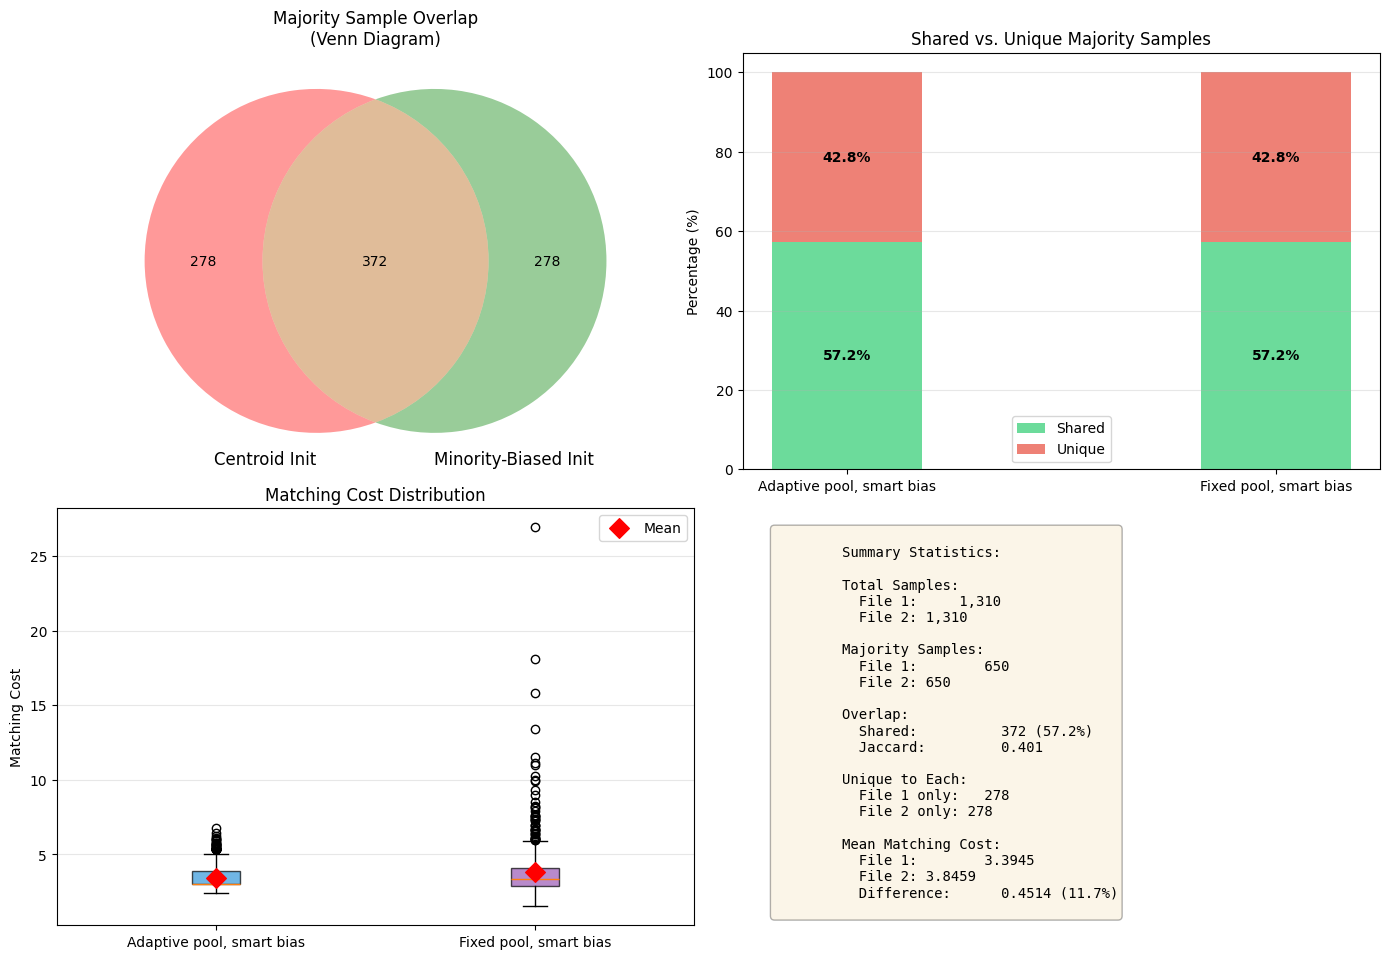


COMPARISON COMPLETE!


In [40]:
# ============================================================================
# COMPARE UNDERSAMPLED DATASETS: Centroid vs. Minority-Biased Initialization
# ============================================================================
# Compare majority samples selected by different seed initialization methods

print("="*80)
print("COMPARING UNDERSAMPLED DATASETS")
print("="*80)

# ============================================================================
# LOAD BOTH DATASETS
# ============================================================================
print("\n1. Loading datasets...")

file1 = "./two_stage_kcenter_results/undersampled_adaptive_pool_smart_init.csv"
file2 = "./two_stage_kcenter_results/undersampled_fixedpool_smart_init.csv"

try:
    df_centroid = pd.read_csv(file1)
    print(f"   ✓ Loaded {file1}")
    print(f"     Total samples: {len(df_centroid):,}")
except FileNotFoundError:
    print(f"   ✗ File not found: {file1}")
    df_centroid = None

try:
    df_minority_biased = pd.read_csv(file2)
    print(f"   ✓ Loaded {file2}")
    print(f"     Total samples: {len(df_minority_biased):,}")
except FileNotFoundError:
    print(f"   ✗ File not found: {file2}")
    df_minority_biased = None

if df_centroid is None or df_minority_biased is None:
    print("\n⚠️ Cannot compare - one or both files not found!")
    print("   Run k-center matching with both seed methods first.")
else:
    # ============================================================================
    # SEPARATE MAJORITY AND MINORITY SAMPLES
    # ============================================================================
    print("\n2. Separating majority and minority samples...")
    
    # Centroid dataset
    centroid_minority = df_centroid[df_centroid[target_col] == 1].copy()
    centroid_majority = df_centroid[df_centroid[target_col] == 0].copy()
    
    print(f"\n   Centroid initialization:")
    print(f"     Minority: {len(centroid_minority):,}")
    print(f"     Majority: {len(centroid_majority):,}")
    
    # Minority-biased dataset
    mb_minority = df_minority_biased[df_minority_biased[target_col] == 1].copy()
    mb_majority = df_minority_biased[df_minority_biased[target_col] == 0].copy()
    
    print(f"\n   Minority-biased initialization:")
    print(f"     Minority: {len(mb_minority):,}")
    print(f"     Majority: {len(mb_majority):,}")
    
    # ============================================================================
    # COMPARE MINORITY SAMPLES (should be identical)
    # ============================================================================
    print(f"\n3. Comparing minority samples (should be identical)...")
    
    centroid_minority_ids = set(centroid_minority['ENROLID'].values)
    mb_minority_ids = set(mb_minority['ENROLID'].values)
    
    minority_same = len(centroid_minority_ids & mb_minority_ids)
    minority_only_centroid = len(centroid_minority_ids - mb_minority_ids)
    minority_only_mb = len(mb_minority_ids - centroid_minority_ids)
    
    print(f"   Shared minority samples: {minority_same:,}")
    print(f"   Only in centroid: {minority_only_centroid:,}")
    print(f"   Only in minority-biased: {minority_only_mb:,}")
    
    if minority_same == len(centroid_minority_ids) == len(mb_minority_ids):
        print(f"   ✓ All minority samples are identical (as expected)")
    else:
        print(f"   ⚠️ WARNING: Minority samples differ! This is unexpected.")
    
    # ============================================================================
    # COMPARE MAJORITY SAMPLES (main comparison)
    # ============================================================================
    print(f"\n4. Comparing majority samples (KEY COMPARISON)...")
    
    centroid_majority_ids = set(centroid_majority['ENROLID'].values)
    mb_majority_ids = set(mb_majority['ENROLID'].values)
    
    n_centroid = len(centroid_majority_ids)
    n_mb = len(mb_majority_ids)
    
    # Compute overlap
    shared_majority = centroid_majority_ids & mb_majority_ids
    only_centroid = centroid_majority_ids - mb_majority_ids
    only_mb = mb_majority_ids - centroid_majority_ids
    
    n_shared = len(shared_majority)
    n_only_centroid = len(only_centroid)
    n_only_mb = len(only_mb)
    
    # Compute percentages
    pct_shared_centroid = (n_shared / n_centroid * 100) if n_centroid > 0 else 0
    pct_shared_mb = (n_shared / n_mb * 100) if n_mb > 0 else 0
    pct_overlap = (n_shared / max(n_centroid, n_mb) * 100) if max(n_centroid, n_mb) > 0 else 0
    
    print(f"\n   📊 Majority Sample Comparison:")
    print(f"   {'─'*60}")
    print(f"   Centroid init:        {n_centroid:,} majority samples")
    print(f"   Minority-biased init: {n_mb:,} majority samples")
    print(f"   {'─'*60}")
    print(f"   Shared (overlap):     {n_shared:,} samples ({pct_overlap:.1f}%)")
    print(f"   Only in centroid:     {n_only_centroid:,} samples ({(n_only_centroid/n_centroid*100):.1f}%)")
    print(f"   Only in minority-biased: {n_only_mb:,} samples ({(n_only_mb/n_mb*100):.1f}%)")
    print(f"   {'─'*60}")
    
    # Jaccard similarity
    union = len(centroid_majority_ids | mb_majority_ids)
    jaccard = (n_shared / union) if union > 0 else 0
    print(f"   Jaccard similarity:   {jaccard:.3f} ({jaccard*100:.1f}%)")
    
    # Interpretation
    print(f"\n   💡 Interpretation:")
    if pct_overlap > 90:
        print(f"      ✓ Very high overlap ({pct_overlap:.1f}%) - seed method has minimal impact")
    elif pct_overlap > 70:
        print(f"      ✓ High overlap ({pct_overlap:.1f}%) - seed method has modest impact")
    elif pct_overlap > 50:
        print(f"      ⚠️ Moderate overlap ({pct_overlap:.1f}%) - seed method matters")
    else:
        print(f"      ⚠️ Low overlap ({pct_overlap:.1f}%) - seed method significantly changes selection")
    
    # ============================================================================
    # ANALYZE DIFFERENCES IN MATCHING QUALITY
    # ============================================================================
    print(f"\n5. Comparing matching quality...")
    
    # Get matching costs for shared vs. unique samples
    if 'match_cost' in centroid_majority.columns and 'match_cost' in mb_majority.columns:
        # Shared samples
        centroid_shared_costs = centroid_majority[
            centroid_majority['ENROLID'].isin(shared_majority)
        ]['match_cost'].dropna()
        
        mb_shared_costs = mb_majority[
            mb_majority['ENROLID'].isin(shared_majority)
        ]['match_cost'].dropna()
        
        # Unique samples
        centroid_unique_costs = centroid_majority[
            centroid_majority['ENROLID'].isin(only_centroid)
        ]['match_cost'].dropna()
        
        mb_unique_costs = mb_majority[
            mb_majority['ENROLID'].isin(only_mb)
        ]['match_cost'].dropna()
        
        print(f"\n   Matching Cost Statistics:")
        print(f"   {'─'*70}")
        print(f"   {'Method':<25} {'Mean':<12} {'Median':<12} {'Max':<12}")
        print(f"   {'─'*70}")
        
        if len(centroid_shared_costs) > 0:
            print(f"   {'Shared (centroid)':<25} {centroid_shared_costs.mean():<12.4f} "
                  f"{centroid_shared_costs.median():<12.4f} {centroid_shared_costs.max():<12.4f}")
        
        if len(mb_shared_costs) > 0:
            print(f"   {'Shared (min-biased)':<25} {mb_shared_costs.mean():<12.4f} "
                  f"{mb_shared_costs.median():<12.4f} {mb_shared_costs.max():<12.4f}")
        
        print(f"   {'─'*70}")
        
        if len(centroid_unique_costs) > 0:
            print(f"   {'Only centroid':<25} {centroid_unique_costs.mean():<12.4f} "
                  f"{centroid_unique_costs.median():<12.4f} {centroid_unique_costs.max():<12.4f}")
        
        if len(mb_unique_costs) > 0:
            print(f"   {'Only min-biased':<25} {mb_unique_costs.mean():<12.4f} "
                  f"{mb_unique_costs.median():<12.4f} {mb_unique_costs.max():<12.4f}")
        
        print(f"   {'─'*70}")
        
        # Overall comparison
        centroid_all_costs = centroid_majority['match_cost'].dropna()
        mb_all_costs = mb_majority['match_cost'].dropna()
        
        print(f"   {'Overall centroid':<25} {centroid_all_costs.mean():<12.4f} "
              f"{centroid_all_costs.median():<12.4f} {centroid_all_costs.max():<12.4f}")
        print(f"   {'Overall min-biased':<25} {mb_all_costs.mean():<12.4f} "
              f"{mb_all_costs.median():<12.4f} {mb_all_costs.max():<12.4f}")
        
        # Which is better?
        cost_diff = mb_all_costs.mean() - centroid_all_costs.mean()
        pct_diff = (cost_diff / mb_all_costs.mean() * 100) if mb_all_costs.mean() > 0 else 0
        
        print(f"\n   Quality comparison:")
        if cost_diff > 0.01:
            print(f"      ✓ Centroid init has LOWER mean cost ({abs(pct_diff):.1f}% better)")
        elif cost_diff < -0.01:
            print(f"      ✓ Minority-biased init has LOWER mean cost ({abs(pct_diff):.1f}% better)")
        else:
            print(f"      = Both methods have similar matching quality ({abs(pct_diff):.1f}% difference)")
    
    # ============================================================================
    # PER-LEAF COMPARISON
    # ============================================================================
    if 'leaf_id' in centroid_majority.columns and 'leaf_id' in mb_majority.columns:
        print(f"\n6. Per-leaf comparison...")
        
        all_leaves = sorted(set(centroid_majority['leaf_id'].unique()) | 
                           set(mb_majority['leaf_id'].unique()))
        
        print(f"\n   {'Leaf':<8} {'Centroid':<12} {'Min-Biased':<12} {'Shared':<12} {'Overlap %':<12}")
        print(f"   {'─'*60}")
        
        for leaf_id in all_leaves:
            if pd.isna(leaf_id):
                continue
                
            centroid_leaf_ids = set(
                centroid_majority[centroid_majority['leaf_id'] == leaf_id]['ENROLID'].values
            )
            mb_leaf_ids = set(
                mb_majority[mb_majority['leaf_id'] == leaf_id]['ENROLID'].values
            )
            
            n_centroid_leaf = len(centroid_leaf_ids)
            n_mb_leaf = len(mb_leaf_ids)
            n_shared_leaf = len(centroid_leaf_ids & mb_leaf_ids)
            
            overlap_pct = (n_shared_leaf / max(n_centroid_leaf, n_mb_leaf) * 100) \
                         if max(n_centroid_leaf, n_mb_leaf) > 0 else 0
            
            print(f"   {int(leaf_id):<8} {n_centroid_leaf:<12} {n_mb_leaf:<12} "
                  f"{n_shared_leaf:<12} {overlap_pct:<12.1f}")
    
    # ============================================================================
    # VISUALIZATION
    # ============================================================================
    print(f"\n7. Creating visualizations...")
    
    try:
        import matplotlib.pyplot as plt
        from matplotlib_venn import venn2
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # 1. Venn diagram
        try:
            venn = venn2([centroid_majority_ids, mb_majority_ids],
                        set_labels=('Centroid Init', 'Minority-Biased Init'),
                        ax=axes[0, 0])
            axes[0, 0].set_title('Majority Sample Overlap\n(Venn Diagram)')
        except:
            # Fallback if matplotlib_venn not available
            axes[0, 0].text(0.5, 0.5, 
                          f'Overlap: {n_shared:,} / {max(n_centroid, n_mb):,}\n'
                          f'Jaccard: {jaccard:.3f}',
                          ha='center', va='center', fontsize=12)
            axes[0, 0].set_title('Majority Sample Overlap')
            axes[0, 0].axis('off')
        
        # 2. Overlap percentages
        categories = ['Adaptive pool, smart bias', 'Fixed pool, smart bias']
        shared_pcts = [pct_shared_centroid, pct_shared_mb]
        unique_pcts = [100 - pct_shared_centroid, 100 - pct_shared_mb]
        
        x = np.arange(len(categories))
        width = 0.35
        
        axes[0, 1].bar(x, shared_pcts, width, label='Shared', color='#2ecc71', alpha=0.7)
        axes[0, 1].bar(x, unique_pcts, width, bottom=shared_pcts, 
                      label='Unique', color='#e74c3c', alpha=0.7)
        
        axes[0, 1].set_ylabel('Percentage (%)')
        axes[0, 1].set_title('Shared vs. Unique Majority Samples')
        axes[0, 1].set_xticks(x)
        axes[0, 1].set_xticklabels(categories)
        axes[0, 1].legend()
        axes[0, 1].grid(axis='y', alpha=0.3)
        
        # Add value labels
        for i, (s, u) in enumerate(zip(shared_pcts, unique_pcts)):
            axes[0, 1].text(i, s/2, f'{s:.1f}%', ha='center', va='center', fontweight='bold')
            axes[0, 1].text(i, s + u/2, f'{u:.1f}%', ha='center', va='center', fontweight='bold')
        
        # 3. Matching cost comparison (if available)
        if 'match_cost' in centroid_majority.columns and 'match_cost' in mb_majority.columns:
            cost_data = [
                centroid_all_costs.values,
                mb_all_costs.values
            ]
            
            bp = axes[1, 0].boxplot(cost_data, labels=categories, patch_artist=True)
            for patch, color in zip(bp['boxes'], ['#3498db', '#9b59b6']):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            axes[1, 0].set_ylabel('Matching Cost')
            axes[1, 0].set_title('Matching Cost Distribution')
            axes[1, 0].grid(axis='y', alpha=0.3)
            
            # Add mean markers
            means = [centroid_all_costs.mean(), mb_all_costs.mean()]
            axes[1, 0].scatter([1, 2], means, color='red', s=100, zorder=10, 
                              marker='D', label='Mean')
            axes[1, 0].legend()
        
        # 4. Summary statistics
        summary_text = f"""
        Summary Statistics:
        
        Total Samples:
          File 1:     {len(df_centroid):,}
          File 2: {len(df_minority_biased):,}
        
        Majority Samples:
          File 1:        {n_centroid:,}
          File 2: {n_mb:,}
        
        Overlap:
          Shared:          {n_shared:,} ({pct_overlap:.1f}%)
          Jaccard:         {jaccard:.3f}
        
        Unique to Each:
          File 1 only:   {n_only_centroid:,}
          File 2 only: {n_only_mb:,}
        """
        
        if 'match_cost' in centroid_majority.columns:
            summary_text += f"""
        Mean Matching Cost:
          File 1:        {centroid_all_costs.mean():.4f}
          File 2: {mb_all_costs.mean():.4f}
          Difference:      {cost_diff:.4f} ({pct_diff:.1f}%)
        """
        
        axes[1, 1].text(0.05, 0.95, summary_text, 
                       transform=axes[1, 1].transAxes,
                       fontsize=10, verticalalignment='top',
                       fontfamily='monospace',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        axes[1, 1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
    except ImportError as e:
        print(f"   ⚠️ Visualization skipped (missing library: {e})")
    
    # ============================================================================
    # SAVE COMPARISON RESULTS
    # ============================================================================
   # print(f"\n8. Saving comparison results...")
    
    # Save lists of ENROLIDs
    comparison_results = {
        'shared_majority_enrolids': list(shared_majority),
        'only_centroid_enrolids': list(only_centroid),
        'only_minoritybiased_enrolids': list(only_mb),
    }
    
    import json
    output_json = "./two_stage_kcenter_results/undersampling_comparison.json"
   # with open(output_json, 'w') as f:
       # json.dump(comparison_results, f, indent=2, default=int)
    
    #print(f"   ✓ Saved ENROLID lists: {output_json}")
    
    # Save summary statistics
    summary_df = pd.DataFrame({
        'Metric': [
            'Total Samples',
            'Minority Samples',
            'Majority Samples',
            'Shared Majority',
            'Unique to Centroid',
            'Unique to Min-Biased',
            'Overlap Percentage',
            'Jaccard Similarity',
        ],
        'Centroid Init': [
            len(df_centroid),
            len(centroid_minority),
            n_centroid,
            n_shared,
            n_only_centroid,
            '-',
            f'{pct_shared_centroid:.1f}%',
            f'{jaccard:.3f}',
        ],
        'Minority-Biased Init': [
            len(df_minority_biased),
            len(mb_minority),
            n_mb,
            n_shared,
            '-',
            n_only_mb,
            f'{pct_shared_mb:.1f}%',
            f'{jaccard:.3f}',
        ]
    })
    

print(f"\n{'='*80}")
print("COMPARISON COMPLETE!")
print(f"{'='*80}")


SANITY CHECK: Smart Seed vs Random Seed for K-Center

📊 K-Center with SMART SEED (argmin mean distance to cases):
  M (candidate pool size): 421
  Total matching cost: 235.53
  Mean matching cost: 4.6182
  Median matching cost: 4.2138
  Max matching cost: 18.0988

🎲 Running 20 K-Center Trials with RANDOM SEEDS:
  Using seed_method='random' parameter
  M = 421 / 842 controls (50.0%)
  Each trial: random seed → k-center → optimal matching

  Seed selection method: 'random'
    Random seed selected: index 102
  Trial  1: Total=236.56, Mean=4.6384
  Seed selection method: 'random'
    Random seed selected: index 836
  Trial  2: Total=236.15, Mean=4.6304
  Seed selection method: 'random'
    Random seed selected: index 788
  Trial  3: Total=235.82, Mean=4.6239
  Seed selection method: 'random'
    Random seed selected: index 414
  Trial  4: Total=237.04, Mean=4.6478
  Seed selection method: 'random'
    Random seed selected: index 189
  Trial  5: Total=234.77, Mean=4.6034
  Seed selection m

/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_3037/1185766247.py:125: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([random_total_costs, [kcenter_total_cost]],


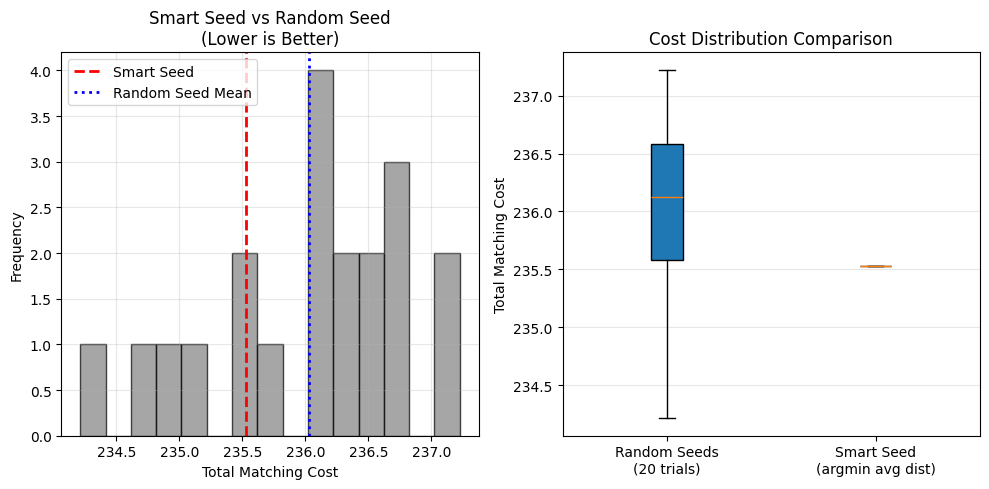



✅ SANITY CHECK COMPLETE
   Smart seed uses: seed_method='smart' (default)
   Random seed uses: seed_method='random' with random_state


In [10]:
# ============================================================================
# SANITY CHECK: Smart Seed vs Random Seed for K-Center
# ============================================================================
# Test if smart seed selection (argmin avg distance) beats random seed selection
# Both use the same k-center farthest-first algorithm, only seed method differs
# NEW: Using seed_method parameter in two_stage_kcenter_then_match()

print("="*80)
print("SANITY CHECK: Smart Seed vs Random Seed for K-Center")
print("="*80)

# ---- SMART SEED (current result from previous cell) ----
kcenter_total_cost = out["match_costs"].sum()
kcenter_mean_cost = out["match_costs"].mean()
kcenter_median_cost = np.median(out["match_costs"])
kcenter_max_cost = out["match_costs"].max()
M_used = len(out["candidate_majority_enrolids"])

print(f"\n📊 K-Center with SMART SEED (argmin mean distance to cases):")
print(f"  M (candidate pool size): {M_used:,}")
print(f"  Total matching cost: {kcenter_total_cost:.2f}")
print(f"  Mean matching cost: {kcenter_mean_cost:.4f}")
print(f"  Median matching cost: {kcenter_median_cost:.4f}")
print(f"  Max matching cost: {kcenter_max_cost:.4f}")

# ---- RANDOM SEED (using new seed_method parameter) ----
# IMPORTANT: M must be < total controls for this test to be meaningful!
n_controls_total = len(leaf_controls)
if M_used >= n_controls_total:
    print(f"\n⚠️ WARNING: M={M_used} >= total controls={n_controls_total}")
    print(f"   Setting M to 50% of controls for meaningful comparison")
    M_test = max(100, n_controls_total // 2)  # At least 100, or 50% of controls
else:
    M_test = M_used

n_random_trials = 20
print(f"\n🎲 Running {n_random_trials} K-Center Trials with RANDOM SEEDS:")
print(f"  Using seed_method='random' parameter")
print(f"  M = {M_test:,} / {n_controls_total:,} controls ({M_test/n_controls_total*100:.1f}%)")
print(f"  Each trial: random seed → k-center → optimal matching\n")

random_total_costs = []
random_mean_costs = []
random_median_costs = []
random_max_costs = []

for trial in range(n_random_trials):
    # Run k-center with RANDOM seed using new parameter
    out_random = two_stage_kcenter_then_match(
        leaf_controls_enrolids=leaf_controls["ENROLID"].to_numpy(),
        leaf_cases_enrolids=leaf_cases["ENROLID"].to_numpy(),
        leaf_nn_matrix_npy=dnn_matrix_npy,
        leaf_nn_enrolids_npy=dnn_enrolids_npy,
        pn_h5_path=pn_h5_path,
        M=M_test,  # Use test M (may differ from smart seed M if adjusted)
        assignment_topk_start=None,  # Exact matching
        seed_method="random",  # NEW: Use random seed
        random_state=42 + trial,  # Different seed each trial
    )
    
    # Record stats
    match_costs_random = out_random["match_costs"]
    random_total_costs.append(match_costs_random.sum())
    random_mean_costs.append(match_costs_random.mean())
    random_median_costs.append(np.median(match_costs_random))
    random_max_costs.append(match_costs_random.max())
    
    if trial < 5:  # Print first 5 trials
        print(f"  Trial {trial+1:2d}: Total={match_costs_random.sum():.2f}, Mean={match_costs_random.mean():.4f}")

# Convert to arrays for statistics
random_total_costs = np.array(random_total_costs)
random_mean_costs = np.array(random_mean_costs)

print(f"\n📈 Random Seed Statistics (over {n_random_trials} trials):")
print(f"  Total cost: {random_total_costs.mean():.2f} ± {random_total_costs.std():.2f}")
print(f"  Mean cost: {random_mean_costs.mean():.4f} ± {random_mean_costs.std():.4f}")
print(f"  Best trial total cost: {random_total_costs.min():.2f}")
print(f"  Worst trial total cost: {random_total_costs.max():.2f}")

# Compare smart seed vs random seed
print(f"\n🎯 Smart Seed vs Random Seed Comparison:")
print(f"  Smart seed (optimal) cost: {kcenter_total_cost:.2f}")
print(f"  Random seed avg cost: {random_total_costs.mean():.2f}")
print(f"  Random seed best cost: {random_total_costs.min():.2f}")
print(f"  Random seed worst cost: {random_total_costs.max():.2f}")

improvement_vs_mean = (random_total_costs.mean() - kcenter_total_cost) / random_total_costs.mean() * 100
improvement_vs_best = (random_total_costs.min() - kcenter_total_cost) / random_total_costs.min() * 100

print(f"\n✅ Smart Seed Improvement:")
print(f"  vs Random Seed Mean: {improvement_vs_mean:+.2f}%")
print(f"  vs Random Seed Best: {improvement_vs_best:+.2f}%")

# Statistical test: how many random seeds beat smart seed?
n_random_better = (random_total_costs < kcenter_total_cost).sum()
print(f"\n📊 Random seeds better than smart seed: {n_random_better}/{n_random_trials} ({n_random_better/n_random_trials*100:.1f}%)")

if improvement_vs_mean > 1:
    print(f"\n🎉 SUCCESS! Smart seed selection (argmin mean distance) beats random seeds!")
elif improvement_vs_mean > 0:
    print(f"\n✅ PASS: Smart seed is better than random, but improvement is modest.")
else:
    print(f"\n⚠️ WARNING: Smart seed is NOT better than random seeds! Seed choice may not matter much.")

# Visualize if possible
try:
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10, 5))
    
    # Plot 1: Total costs distribution
    plt.subplot(1, 2, 1)
    plt.hist(random_total_costs, bins=15, alpha=0.7, color='gray', edgecolor='black')
    plt.axvline(kcenter_total_cost, color='red', linestyle='--', linewidth=2, label='Smart Seed')
    plt.axvline(random_total_costs.mean(), color='blue', linestyle=':', linewidth=2, label='Random Seed Mean')
    plt.xlabel('Total Matching Cost')
    plt.ylabel('Frequency')
    plt.title('Smart Seed vs Random Seed\n(Lower is Better)')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Plot 2: Box plot comparison
    plt.subplot(1, 2, 2)
    plt.boxplot([random_total_costs, [kcenter_total_cost]], 
                labels=['Random Seeds\n(20 trials)', 'Smart Seed\n(argmin avg dist)'],
                patch_artist=True)
    plt.ylabel('Total Matching Cost')
    plt.title('Cost Distribution Comparison')
    plt.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    plt.show()
    
except ImportError:
    print("\n(matplotlib not available for visualization)")

print("\n" + "="*80)
print(f"\n✅ SANITY CHECK COMPLETE")
print(f"   Smart seed uses: seed_method='smart' (default)")
print(f"   Random seed uses: seed_method='random' with random_state")
print("="*80)


COMPARING K-CENTER SEED INITIALIZATION METHODS

Test leaf: 2
  Cases: 114
  Controls: 14,487

Preprocessed features: (14487, 44)
[leaf 2] computing d_nn for n=14,487 -> ~0.84 GB float32


leaf 2 d_nn: 100%|██████████| 20/20 [00:01<00:00, 13.72it/s]


[leaf 2] saved:
  ./precomputed_distances/leaf_dnn_oct_stratifier/leaf_2_dnn_matrix.npy
  ./precomputed_distances/leaf_dnn_oct_stratifier/leaf_2_dnn_enrolids.npy
  Control-control distances: ./precomputed_distances/leaf_dnn_oct_stratifier/leaf_2_dnn_matrix.npy

RUNNING K-CENTER WITH DIFFERENT SEED INITIALIZATIONS (M=7,243)


────────────────────────────────────────────────────────────────────────────────
📍 Seed Method: SMART
────────────────────────────────────────────────────────────────────────────────
  Seed selection method: 'smart'
    Smart seed selected: index 10384 (mean dist to cases: 4.3535)
  ✓ Matching complete
    Seed index: 10384
    Total matching cost: 299.54
    Mean cost: 2.6275
    Median cost: 2.6367
    Max cost: 3.9992

────────────────────────────────────────────────────────────────────────────────
📍 Seed Method: CENTROID
────────────────────────────────────────────────────────────────────────────────
  Seed selection method: 'centroid'
    Centroid seed selecte

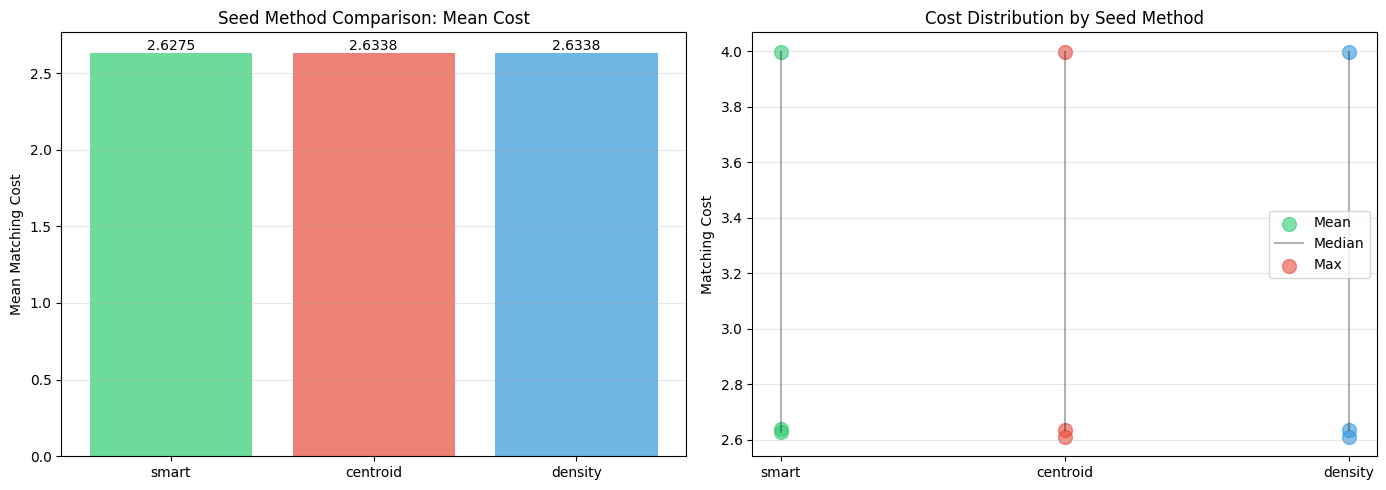


COMPARISON COMPLETE!


In [11]:
# ============================================================================
# COMPARE ALL SEED INITIALIZATION METHODS
# ============================================================================
# Compare 3 seed initialization strategies for k-center:
# 1. Minority-biased (smart): argmin mean distance to cases
# 2. Centroid: closest to majority centroid
# 3. Max-density: highest local density in majority space

print("="*80)
print("COMPARING K-CENTER SEED INITIALIZATION METHODS")
print("="*80)

import two_stage_kcenter_match
importlib.reload(two_stage_kcenter_match)
from two_stage_kcenter_match import two_stage_kcenter_then_match

# Test on largest leaf
leaf_id = df_with_leaves['leaf_assignment'].mode()[0]
leaf_df = df_with_leaves[df_with_leaves['leaf_assignment'] == leaf_id].copy()
leaf_cases = leaf_df[leaf_df[target_col] == 1].copy()
leaf_controls = leaf_df[leaf_df[target_col] == 0].copy()

print(f"\nTest leaf: {int(leaf_id)}")
print(f"  Cases: {len(leaf_cases):,}")
print(f"  Controls: {len(leaf_controls):,}")

# Prepare data (same as before)
from model_pipeline import get_preprocessor, get_bin_flag_columns
from sklearn.impute import SimpleImputer

exclude_cols_leaf = ["cost_stratum_2018"] + COST_COLUMNS + ["leaf_assignment", "predicted_cost_stratum"]
drop_cols_leaf = ['ENROLID', target_col] + exclude_cols_leaf
feature_cols_leaf = [c for c in leaf_controls.columns if c not in drop_cols_leaf]

numeric_cols_leaf = leaf_controls[feature_cols_leaf].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_leaf = leaf_controls[feature_cols_leaf].select_dtypes(include=["object", "category"]).columns.tolist()

leaf_controls_preprocessed = leaf_controls[feature_cols_leaf].copy()
if numeric_cols_leaf:
    imputer = SimpleImputer(strategy='median')
    leaf_controls_preprocessed[numeric_cols_leaf] = imputer.fit_transform(leaf_controls_preprocessed[numeric_cols_leaf])
if categorical_cols_leaf:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    leaf_controls_preprocessed[categorical_cols_leaf] = cat_imputer.fit_transform(leaf_controls_preprocessed[categorical_cols_leaf])

bin_feats_leaf = get_bin_flag_columns(leaf_controls_preprocessed)
num_feats_leaf = [c for c in numeric_cols_leaf if c not in bin_feats_leaf]

preprocessor_leaf = get_preprocessor(
    df=leaf_controls_preprocessed,
    categorical_cols=categorical_cols_leaf,
    numeric_cols=num_feats_leaf,
    verbose=False
)
X_majority_leaf = preprocessor_leaf.fit_transform(leaf_controls_preprocessed)

print(f"\nPreprocessed features: {X_majority_leaf.shape}")

# Precompute distances (if not already done)
from precompute_distances import precompute_leaf_dnn_memmap
majority_enrolids_leaf = leaf_controls["ENROLID"].to_numpy()

dnn_matrix_npy, dnn_enrolids_npy = precompute_leaf_dnn_memmap(
    X_majority_leaf=X_majority_leaf,
    majority_enrolids_leaf=majority_enrolids_leaf,
    out_dir="./precomputed_distances/leaf_dnn_oct_stratifier",
    leaf_id=str(int(leaf_id)),
    batch_size=750,
)

print(f"  Control-control distances: {dnn_matrix_npy}")

# Test all 3 seed methods
M_test = min(8000, len(leaf_controls) // 2)
seed_methods = ["smart", "centroid", "density"]
results_comparison = {}

print(f"\n{'='*80}")
print(f"RUNNING K-CENTER WITH DIFFERENT SEED INITIALIZATIONS (M={M_test:,})")
print(f"{'='*80}\n")

for method in seed_methods:
    print(f"\n{'─'*80}")
    print(f"📍 Seed Method: {method.upper()}")
    print(f"{'─'*80}")
    
    try:
        out = two_stage_kcenter_then_match(
            leaf_controls_enrolids=leaf_controls["ENROLID"].to_numpy(),
            leaf_cases_enrolids=leaf_cases["ENROLID"].to_numpy(),
            leaf_nn_matrix_npy=dnn_matrix_npy,
            leaf_nn_enrolids_npy=dnn_enrolids_npy,
            pn_h5_path=pn_h5_path,
            M=M_test,
            assignment_topk_start=None,  # Exact matching
            seed_method=method,
            X_majority_leaf=X_majority_leaf if method == "centroid" else None,
            density_epsilon=None,  # Auto-select
            density_percentile=10.0,
        )
        
        total_cost = float(out["match_costs"].sum())
        mean_cost = float(out["match_costs"].mean())
        median_cost = float(np.median(out["match_costs"]))
        max_cost = float(out["match_costs"].max())
        
        results_comparison[method] = {
            "total_cost": total_cost,
            "mean_cost": mean_cost,
            "median_cost": median_cost,
            "max_cost": max_cost,
            "seed_idx": out["seed_idx"],
            "seed_enrolid": out["seed_enrolid"],
            "n_candidates": len(out["candidate_majority_enrolids"]),
        }
        
        print(f"  ✓ Matching complete")
        print(f"    Seed index: {out['seed_idx']}")
        print(f"    Total matching cost: {total_cost:.2f}")
        print(f"    Mean cost: {mean_cost:.4f}")
        print(f"    Median cost: {median_cost:.4f}")
        print(f"    Max cost: {max_cost:.4f}")
        
    except Exception as e:
        print(f"  ✗ ERROR: {e}")
        import traceback
        traceback.print_exc()
        continue

# ============================================================================
# COMPARISON RESULTS
# ============================================================================
print(f"\n\n{'='*80}")
print("SEED INITIALIZATION COMPARISON RESULTS")
print(f"{'='*80}\n")

if len(results_comparison) > 0:
    # Create comparison table
    print(f"{'Seed Method':<20} {'Total Cost':<15} {'Mean Cost':<15} {'Median Cost':<15} {'Max Cost':<15}")
    print(f"{'─'*20} {'─'*15} {'─'*15} {'─'*15} {'─'*15}")
    
    for method, res in results_comparison.items():
        print(f"{method.upper():<20} {res['total_cost']:<15.2f} {res['mean_cost']:<15.4f} {res['median_cost']:<15.4f} {res['max_cost']:<15.4f}")
    
    # Find best method
    best_method = min(results_comparison.keys(), key=lambda k: results_comparison[k]["mean_cost"])
    worst_method = max(results_comparison.keys(), key=lambda k: results_comparison[k]["mean_cost"])
    
    best_cost = results_comparison[best_method]["mean_cost"]
    worst_cost = results_comparison[worst_method]["mean_cost"]
    improvement = ((worst_cost - best_cost) / worst_cost) * 100
    
    print(f"\n🏆 Best method: {best_method.upper()} (mean cost: {best_cost:.4f})")
    print(f"📉 Worst method: {worst_method.upper()} (mean cost: {worst_cost:.4f})")
    print(f"📊 Improvement: {improvement:.2f}%")
    
    # Interpretation
    print(f"\n{'='*80}")
    print("INTERPRETATION")
    print(f"{'='*80}")
    print(f"""
📖 Seed Initialization Methods:

1. MINORITY-BIASED (smart):
   - Selects control closest to all minority samples
   - Optimizes for coverage of minority class
   - Expected to have lowest cost (best for matching quality)

2. CENTROID:
   - Selects control closest to majority centroid
   - Starts from "representative" majority point
   - May provide good general coverage

3. MAX-DENSITY:
   - Selects control from densest region
   - Starts from typical/common majority profile
   - May be good if majority has clear clusters

💡 Recommendation:
   Use '{best_method.upper()}' for best matching quality (lowest cost).
   
   However, if matching costs are very similar (<1% difference),
   all methods are comparable and 'smart' (minority-biased) is recommended
   as the default since it directly optimizes for the matching objective.
""")
    
    # Visualize
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Mean cost comparison
    methods = list(results_comparison.keys())
    mean_costs = [results_comparison[m]["mean_cost"] for m in methods]
    colors = ['#2ecc71' if m == best_method else '#e74c3c' if m == worst_method else '#3498db' for m in methods]
    
    axes[0].bar(methods, mean_costs, color=colors, alpha=0.7)
    axes[0].set_ylabel('Mean Matching Cost')
    axes[0].set_title('Seed Method Comparison: Mean Cost')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, (method, cost) in enumerate(zip(methods, mean_costs)):
        axes[0].text(i, cost, f'{cost:.4f}', ha='center', va='bottom')
    
    # Boxplot would need full distributions - show max/median/mean instead
    for i, method in enumerate(methods):
        res = results_comparison[method]
        axes[1].scatter([i]*3, [res['mean_cost'], res['median_cost'], res['max_cost']], 
                       alpha=0.6, s=100, color=colors[i])
        axes[1].plot([i, i], [res['mean_cost'], res['max_cost']], 'k-', alpha=0.3)
    
    axes[1].set_xticks(range(len(methods)))
    axes[1].set_xticklabels(methods)
    axes[1].set_ylabel('Matching Cost')
    axes[1].set_title('Cost Distribution by Seed Method')
    axes[1].legend(['Mean', 'Median', 'Max'], loc='best')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./seed_method_comparison.png', dpi=150, bbox_inches='tight')
    print(f"\n💾 Saved plot: ./seed_method_comparison.png")
    plt.show()

print(f"\n{'='*80}")
print("COMPARISON COMPLETE!")
print(f"{'='*80}")

# Keep training nested OCT on giant leaf

In [28]:
# Fit a nested OCT model within leaf 2 to predict cost_stratum_2018
import importlib
import oct_stratifier
importlib.reload(oct_stratifier)
from oct_stratifier import train_stratifier_oct,train_stratifier_oct_tuned, train_stratifier_oct_binary_tuned


In [37]:
# Get features ACTUALLY used in parent OCT splits
# Extract from tree structure, not just importance scores
print("="*80)
print("EXTRACTING PARENT OCT SPLIT FEATURES FROM TREE STRUCTURE")
print("="*80)

try:
    # IAI trees have methods to query tree structure
    num_nodes = model.get_num_nodes()
    parent_split_features = set()
    
    print(f"Parent OCT has {num_nodes} nodes")
    print(f"Iterating through nodes to find split features...\n")
    
    # Iterate through all nodes to find split features
    for node_id in range(1, num_nodes + 1):
        try:
            # Check if node is a split node (has children)
            lower_child = model.get_lower_child(node_id)
            upper_child = model.get_upper_child(node_id)
            
            if lower_child > 0 and upper_child > 0:  # It's a split node
                # Get the split feature
                split_feature = model.get_split_feature(node_id)
                parent_split_features.add(split_feature)
                
                # Get split threshold for context
                try:
                    threshold = model.get_split_threshold(node_id)
                    print(f"  Node {node_id}: splits on '{split_feature}' at threshold {threshold:.3f}")
                except:
                    print(f"  Node {node_id}: splits on '{split_feature}'")
        except Exception as e:
            pass  # Node is a leaf or error, skip
    
    parent_split_features = sorted(list(parent_split_features))
    print(f"\n✓ Found {len(parent_split_features)} UNIQUE features used in parent splits:")
    print(f"  {parent_split_features}")
    
except Exception as e:
    print(f"⚠ Could not extract from tree structure: {e}")
    print("  Falling back to variable_importance()...\n")
    
    # Fallback: Use variable_importance with threshold
    parent_feature_importance = model.variable_importance()
    parent_split_features = parent_feature_importance[parent_feature_importance["Importance"] > 0]["Feature"].tolist()
    print(f"  Features with importance > 0: {parent_split_features}")

print(f"\n{len(parent_split_features)} features to exclude from nested OCT")

# For nested OCT, exclude:
# 1. COST_COLUMNS (outcome-related features)
# 2. Features used in parent OCT splits (to find different stratification patterns)
nested_stratification_cols = [
    col for col in feature_cols if col not in parent_split_features]

print(f"\nNested OCT will use {len(nested_stratification_cols)} features")
print(f"  Excluded (parent split features): {parent_split_features}")
print(f"  Sample included features: {nested_stratification_cols[:10]}")



EXTRACTING PARENT OCT SPLIT FEATURES FROM TREE STRUCTURE
Parent OCT has 7 nodes
Iterating through nodes to find split features...

  Node 1: splits on '2017Q4_max_ckd_stage' at threshold 4.500
  Node 3: splits on '2017Q4_direct_ckd_cost' at threshold 0.389
  Node 5: splits on 'quarterly_max_2017' at threshold 1.233

✓ Found 3 UNIQUE features used in parent splits:
  ['2017Q4_direct_ckd_cost', '2017Q4_max_ckd_stage', 'quarterly_max_2017']

3 features to exclude from nested OCT

Nested OCT will use 75 features
  Excluded (parent split features): ['2017Q4_direct_ckd_cost', '2017Q4_max_ckd_stage', 'quarterly_max_2017']
  Sample included features: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism']


In [ ]:

print(f"\nTraining nested OCT on leaf 2:")
# After your pre-balancing step:
pipeline_results = train_stratifier_oct_binary_tuned(
    df_prebalanced=leaf_2_df,
    stratification_cols=nested_stratification_cols,
    CAT_COLUMNS=CAT_COLUMNS,
    TRUE_NUM_COLUMNS=TRUE_NUM_COLUMNS,
    param_grid = {
            "max_depth": [5,7,9],
            "minbucket": [25],
            "cp": [0]
        },
    target="highcost_gt_200000",
)
print(f"\n✓ Nested OCT model trained successfully")

# Access results:
X_leaf2_nested = pipeline_results['df_with_leaves']
nested_model = pipeline_results['model']
nested_preprocessor = pipeline_results['preprocessor']
nested_feature_names = pipeline_results['feature_names']
ohe = nested_preprocessor.named_transformers_["ohe"]
cat_cols = ['ENROLID','INCOME_LEVEL','AGEGRP','SEX','REGION','cost_pattern_2017','cost_stability_2017','lab_monitoring_intensity']

cats = dict(zip(cat_cols, ohe.categories_))
baseline_cost_pattern  = cats["cost_pattern_2017"][0]
baseline_cost_stability = cats["cost_stability_2017"][0]

baseline_cost_pattern, baseline_cost_stability

nested_model


Training nested OCT on leaf 2:
Using full dataset for tuning: 21,056 rows
Target distribution (tuning base):
  Class 0: 20,712 (98.4%)
  Class 1: 344 (1.6%)
Total parameter combinations before sampling: 3

[1/3] Evaluating params: {'max_depth': 5, 'minbucket': 25, 'cp': 0}
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_co

Fitted OptimalTreeClassifier:
  1) Predict: 0 (98.37%), [20712,344], 21056 points, error 0.01634

In [25]:
# Save the final model and dataframe with leaves
import os
import pickle

# Create output directory if it doesn't exist
output_dir = "saved_models"
os.makedirs(output_dir, exist_ok=True)

# Save the model, preprocessor, and feature names
model_path = os.path.join(output_dir, "oct_binary_model_cp0_nested1.pkl")
with open(model_path, 'wb') as f:
    pickle.dump({
        'model': nested_model,
        'preprocessor': nested_preprocessor,
        'feature_names': nested_feature_names
    }, f)
print(f"✓ Saved model to: {model_path}")

# Save the dataframe with leaves
df_path = os.path.join(output_dir, "df_binary_model_cp0_nested1.csv")
X_leaf2_nested.to_csv(df_path, index=False)
print(f"✓ Saved dataframe with leaves to: {df_path}")
print(f"  Shape: {X_leaf2_nested.shape}")
print(f"  Columns: {X_leaf2_nested.columns.tolist()[:10]}...")  # Show first 10 columns


✓ Saved model to: saved_models/oct_binary_model_cp0_nested1.pkl
✓ Saved dataframe with leaves to: saved_models/df_binary_model_cp0_nested1.csv
  Shape: (21707, 100)
  Columns: ['ENROLID', 'annual_cost_2017', 'highcost_gt_50000_2017', 'highcost_gt_75000_2017', 'highcost_gt_100000_2017', 'highcost_gt_200000_2017', 'highcost_gt_300000_2017', 'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'INCOME_LEVEL']...


# Run FULL PushPull MILP sampler within each leaf subgroup (NO PRUNING)
This solves the complete optimization problem on ALL nodes and ALL edges -- currently not tractable for giant leaf



In [62]:
import sys
sys.path.append('balancing_functions')
# IMPORTANT: Import the module first, then reload, then import the class
# This ensures we get the latest version of the class after any file changes
import balancing_functions.pushpull_sampler as pushpull_module
importlib.reload(pushpull_module)
from balancing_functions.pushpull_sampler import PushPullSampler

In [63]:
# ============================================================================
# PRECOMPUTE DISTANCES FOR ALL LEAVES (SPEED OPTIMIZATION)
# ============================================================================
# This cell precomputes preprocessed features and distance matrices for each leaf
# This avoids recomputing distances multiple times during MILP optimization

print("="*80)
print("PRECOMPUTING DISTANCES FOR ALL LEAVES")
print("="*80)

import os
from precompute_distances import compute_distances_batched, precompute_leaf_dnn_memmap
from sklearn.metrics import pairwise_distances

# Create output directory for precomputed distances
distances_cache_dir = "./precomputed_distances/pushpull_per_leaf"
os.makedirs(distances_cache_dir, exist_ok=True)

# Get unique leaves from NESTED OCT
unique_leaves = sorted(df_with_leaves['leaf_assignment'].unique())
print(f"\nPrecomputing for {len(unique_leaves)} leaves...")

# Initialize sampler for preprocessing (using optimized version with precomputed distance support)
from balancing_functions.pushpull_sampler_precomputed import PushPullSamplerPrecomputed

milp_sampler = PushPullSamplerPrecomputed(
    random_state=42,
    binary_group=target_col,
    uid_col="ENROLID",
)

exclude_cols = ["cost_stratum_2018"] + COST_COLUMNS + ["leaf_assignment", "predicted_cost_stratum"]

# Store precomputed data for each leaf
precomputed_data = {}

for leaf_id in unique_leaves:
    if leaf_id == 2:
        continue
    
    print(f"\n{'='*60}")
    print(f"Leaf {leaf_id}")
    print(f"{'='*60}")
    
    # Get data for this leaf
    leaf_df = df_with_leaves[df_with_leaves['leaf_assignment'] == leaf_id].copy()
    leaf_cases = leaf_df[leaf_df[target_col] == 1].copy()
    leaf_controls = leaf_df[leaf_df[target_col] == 0].copy()
    
    n_cases = len(leaf_cases)
    n_controls = len(leaf_controls)
    
    print(f"  Cases: {n_cases}, Controls: {n_controls}")
    
    # Skip if no cases or no controls or already balanced
    if n_cases == 0 or n_controls == 0 or n_controls <= n_cases:
        print(f"  ⊘ Skipping (no optimization needed)")
        precomputed_data[leaf_id] = {
            'skip': True,
            'reason': 'no_optimization_needed'
        }
        continue
    
    try:
        # Preprocess features (this is the expensive part)
        print(f"  ► Preprocessing features...")
        X_cases_preprocessed, X_controls_preprocessed = milp_sampler.get_preprocessed_control_case_features(
            cases=leaf_cases,
            controls=leaf_controls,
            exclude_cols_matching=exclude_cols,
            verbose=False
        )
        
        print(f"    Cases: {X_cases_preprocessed.shape}, Controls: {X_controls_preprocessed.shape}")
        
        # Compute case-control distances (D_pn)
        print(f"  ► Computing case-control distances...")
        D_pn = pairwise_distances(X_cases_preprocessed, X_controls_preprocessed, metric='euclidean')
        print(f"    D_pn shape: {D_pn.shape}, size: {D_pn.nbytes / 1e6:.1f} MB")
        
        # Compute control-control distances (D_nn) - only if needed for optimization
        print(f"  ► Computing control-control distances...")
        D_nn = pairwise_distances(X_controls_preprocessed, X_controls_preprocessed, metric='euclidean')
        print(f"    D_nn shape: {D_nn.shape}, size: {D_nn.nbytes / 1e6:.1f} MB")
        
        # Save to cache
        leaf_cache_path = os.path.join(distances_cache_dir, f"leaf_{leaf_id}")
        np.save(f"{leaf_cache_path}_Dpn.npy", D_pn.astype(np.float32))
        np.save(f"{leaf_cache_path}_Dnn.npy", D_nn.astype(np.float32))
        np.save(f"{leaf_cache_path}_X_cases.npy", X_cases_preprocessed.astype(np.float32))
        np.save(f"{leaf_cache_path}_X_controls.npy", X_controls_preprocessed.astype(np.float32))
        
        # Store metadata
        precomputed_data[leaf_id] = {
            'skip': False,
            'n_cases': n_cases,
            'n_controls': n_controls,
            'X_cases_preprocessed': X_cases_preprocessed,
            'X_controls_preprocessed': X_controls_preprocessed,
            'D_pn': D_pn,
            'D_nn': D_nn,
            'cache_path': leaf_cache_path,
            'leaf_cases': leaf_cases,
            'leaf_controls': leaf_controls,
        }
        
        print(f"  ✓ Cached to: {leaf_cache_path}_*.npy")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        precomputed_data[leaf_id] = {
            'skip': True,
            'reason': f'error: {str(e)}'
        }

print(f"\n{'='*80}")
print(f"PRECOMPUTATION COMPLETE")
print(f"{'='*80}")
print(f"Leaves ready for optimization: {sum(1 for v in precomputed_data.values() if not v.get('skip', True))}")
print(f"Leaves skipped: {sum(1 for v in precomputed_data.values() if v.get('skip', False))}")
print(f"Total cached files: {len([f for f in os.listdir(distances_cache_dir) if f.endswith('.npy')])}")
print(f"Cache directory: {distances_cache_dir}")


PRECOMPUTING DISTANCES FOR ALL LEAVES

Precomputing for 7 leaves...

Leaf 5
  Cases: 210, Controls: 6223
  ► Preprocessing features...
    Cases: (210, 44), Controls: (6223, 44)
  ► Computing case-control distances...
    D_pn shape: (210, 6223), size: 10.5 MB
  ► Computing control-control distances...
    D_nn shape: (6223, 6223), size: 309.8 MB
  ✓ Cached to: ./precomputed_distances/pushpull_per_leaf/leaf_5_*.npy

Leaf 8
  Cases: 99, Controls: 1007
  ► Preprocessing features...
    Cases: (99, 44), Controls: (1007, 44)
  ► Computing case-control distances...
    D_pn shape: (99, 1007), size: 0.8 MB
  ► Computing control-control distances...
    D_nn shape: (1007, 1007), size: 8.1 MB
  ✓ Cached to: ./precomputed_distances/pushpull_per_leaf/leaf_8_*.npy

Leaf 9
  Cases: 64, Controls: 101
  ► Preprocessing features...
    Cases: (64, 44), Controls: (101, 44)
  ► Computing case-control distances...
    D_pn shape: (64, 101), size: 0.1 MB
  ► Computing control-control distances...
    D_n

In [ ]:

# ============================================================================
# RUNNING PUSHPULL SAMPLING ON LEAVES (WITH PRECOMPUTED DISTANCES)
# ============================================================================
# This cell uses precomputed distances from the previous cell for speed

# Parameters for pushpull sampling
final_ratio = 1.0  # Target ratio of controls to cases
w = 0.5  # Weight for push-pull objective
exclude_cols = ["cost_stratum_2018"] + COST_COLUMNS + ["leaf_assignment", "predicted_cost_stratum"]

print("="*80)
print("RUNNING PUSHPULL SAMPLING ON LEAVES (OPTIMIZED)")
print("="*80)
print(f"Using precomputed distances from: {distances_cache_dir}")
print(f"Leaves to process: {sum(1 for v in precomputed_data.values() if not v.get('skip', True))}")
print("="*80)

# Store results for each leaf
leaf_results = []
all_undersampled = []

# Note: milp_sampler already initialized in previous cell (PushPullSamplerPrecomputed)
# No need to reinitialize - we'll reuse the same instance with precomputed distances

for leaf_id in sorted(precomputed_data.keys()):
    if leaf_id == 2:
        continue
    
    print(f"\n{'='*80}")
    print(f"Processing Leaf {leaf_id}")
    print(f"{'='*80}")
    
    # Check if leaf should be skipped
    if precomputed_data[leaf_id].get('skip', False):
        reason = precomputed_data[leaf_id].get('reason', 'unknown')
        print(f"  ⊘ Skipping: {reason}")
        
        # If skipped but we have original data, keep it as-is
        leaf_df = df_with_leaves[df_with_leaves['leaf_assignment'] == leaf_id].copy()
        if len(leaf_df) > 0:
            all_undersampled.append(leaf_df)
        continue
    
    # Get precomputed data for this leaf
    leaf_data = precomputed_data[leaf_id]
    leaf_cases = leaf_data['leaf_cases']
    leaf_controls = leaf_data['leaf_controls']
    X_cases_preprocessed = leaf_data['X_cases_preprocessed']
    X_controls_preprocessed = leaf_data['X_controls_preprocessed']
    
    n_cases = leaf_data['n_cases']
    n_controls = leaf_data['n_controls']
    
    print(f"  Cases (minority): {n_cases}")
    print(f"  Controls (majority): {n_controls}")
    print(f"  ✓ Using precomputed features: cases {X_cases_preprocessed.shape}, controls {X_controls_preprocessed.shape}")

    ########### below is like solve_pushpull_normalized_MILP ########################
    # Use precomputed features (NO REPROCESSING!)
    try:
        
        # CRITICAL: Use ALL controls (no node pruning)
        # candidate_indices = all control indices (0 to n_controls-1)
        candidate_indices = list(range(n_controls))
        
        # CRITICAL: Set pruning parameters to include ALL edges
        # top_k_case_ctrl: set to n_controls (or larger) to get ALL case-control edges
        # The patched method handles L >= C case properly
        top_k_case_ctrl = n_controls
        
        # L_pairs: set to n_controls - 1 to include all control-control pairs
        # (each control paired with all others)
        L_pairs = n_controls - 1 if n_controls > 1 else 0
        
        print(f"  Using ALL {n_controls} controls (no node pruning)")
        print(f"  Using ALL case-control edges (top_k_case_ctrl={top_k_case_ctrl})")
        print(f"  Using ALL control-control pairs (L_pairs={L_pairs})")
        print(f"  Total possible control pairs: {n_controls * (n_controls - 1) // 2}")
        
        # Get precomputed distances for this leaf
        D_pn = leaf_data['D_pn']
        D_nn = leaf_data['D_nn']
        
        # Compute extreme points first (required for normalized weighted objective)
        # Using PRECOMPUTED distances for maximum speed!
        print(f"  Computing extreme points (with precomputed distances)...")
        ext = milp_sampler.compute_pushpull_extreme_points(
            X_cases_preprocessed, 
            X_controls_preprocessed, 
            candidate_indices,
            final_ratio=final_ratio,
            top_k_case_ctrl=top_k_case_ctrl, # ALL edges
            L_pairs=L_pairs, # ALL pairs
            verbose=False,
            D_pn_precomputed=D_pn,  # ⚡ PRECOMPUTED!
            D_nn_precomputed=D_nn   # ⚡ PRECOMPUTED!
        )
        print(f"  Extreme points: f1=[{ext['f1_min']:.4f}, {ext['f1_max']:.4f}], "
              f"f2=[{ext['f2_min']:.4f}, {ext['f2_max']:.4f}]")
        
        # Solve FULL MILP with all nodes and edges
        # Using PRECOMPUTED distances for maximum speed!
        print(f"  Solving FULL MILP optimization (with precomputed distances)...")
        result = milp_sampler.solve_pushpull_MILP(
            X_cases_preprocessed,
            X_controls_preprocessed,
            candidate_indices,
            final_ratio=final_ratio,
            top_k_case_ctrl=top_k_case_ctrl,  # ALL edges
            L_pairs=L_pairs,  # ALL pairs
            objective_mode="weighted",
            w=w,
            ext=ext,
            verbose=True,
            D_pn_precomputed=D_pn,  # ⚡ PRECOMPUTED!
            D_nn_precomputed=D_nn   # ⚡ PRECOMPUTED!
        )
        
        selected_control_indices = result["selected"]
        n_selected = len(selected_control_indices)
        
        print(f"  ✓ Selected {n_selected} controls out of {n_controls}")
        print(f"  ✓ Objective value: {result.get('objective', 'N/A')}")
        
        # Reconstruct undersampled dataframe from original dataframes
        undersampled_leaf_full = pd.concat([
            leaf_cases,  # All cases
            leaf_controls.iloc[selected_control_indices]  # Selected controls
        ], ignore_index=True)
        
        all_undersampled.append(undersampled_leaf_full)
        
        # Store leaf results
        leaf_results.append({
            'leaf_id': leaf_id,
            'n_cases': n_cases,
            'n_controls_original': n_controls,
            'n_controls_selected': n_selected,
            'final_size': len(undersampled_leaf_full),
            'milp_obj': result.get('objective', None),
            'f1_value': result.get('f1', None),
            'f2_value': result.get('f2', None),
            'n_variables': result.get('n_variables', None),
            'n_constraints': result.get('n_constraints', None)
        })
        
        print(f"  ✓ Final size: {len(undersampled_leaf_full)} (cases + selected controls)")
        
    except Exception as e:
        import traceback
        print(f"  ✗ Error processing leaf {leaf_id}: {e}")
        print(f"  Traceback: {traceback.format_exc()}")
        # Fallback: keep all data from this leaf
        all_undersampled.append(leaf_df)
        continue

# Combine all leaf results
if all_undersampled:
    final_undersampled = pd.concat(all_undersampled, ignore_index=True)
    
    print(f"\n{'='*80}")
    print("FINAL RESULTS - NESTED OCT PUSHPULL SAMPLING")
    print(f"{'='*80}")
    print(f"Original nested data (X_leaf2_nested): {len(X_leaf2_nested):,} samples")
    print(f"Undersampled data: {len(final_undersampled):,} samples")
    print(f"Reduction: {(1 - len(final_undersampled)/len(X_leaf2_nested))*100:.1f}%")
    print(f"\nTarget distribution:")
    print(final_undersampled[target_col].value_counts())
    
    # Save results
    results_dir = "./pushpull_per_leaf_results"
    os.makedirs(results_dir, exist_ok=True)
    
    save_path = f"{results_dir}/pushpull_NESTED_leaf2_FULL_MILP_ratio_{final_ratio:.1f}.csv"
    final_undersampled.to_csv(save_path, index=False)
    print(f"\n✓ Saved undersampled data to: {save_path}")
    
    # Save leaf-level summary
    leaf_summary_df = pd.DataFrame(leaf_results)
    summary_path = f"{results_dir}/leaf_summary_NESTED_leaf2_FULL_MILP_ratio_{final_ratio:.1f}.csv"
    leaf_summary_df.to_csv(summary_path, index=False)
    print(f"✓ Saved leaf summary to: {summary_path}")
    
    print(f"\nLeaf-level summary:")
    print(leaf_summary_df.to_string(index=False))
else:
    print("\n⚠ No leaves processed successfully")


RUNNING PUSHPULL SAMPLING ON LEAVES (OPTIMIZED)
Using precomputed distances from: ./precomputed_distances/pushpull_per_leaf
Leaves to process: 5

Processing Leaf 5
  Cases (minority): 210
  Controls (majority): 6223
  ✓ Using precomputed features: cases (210, 44), controls (6223, 44)
  Using ALL 6223 controls (no node pruning)
  Using ALL case-control edges (top_k_case_ctrl=6223)
  Using ALL control-control pairs (L_pairs=6222)
  Total possible control pairs: 19359753
  Computing extreme points (with precomputed distances)...
pressed CTRL-C 1 times (5 times for forcing termination)
pressed CTRL-C 2 times (5 times for forcing termination)


# Evaluate final OCT


In [4]:
import os, pickle
import model_IAI
importlib.reload(model_IAI)
from model_IAI import evaluate_binary_oct, finetune_oct
ratio_values = [1.0]

{'excess_ROC_s|v': {'point': 0.18140613101087913,
  'lo': 0.12228508888854105,
  'hi': 0.23872991865657928,
  'se_boot': 0.02964826192017382,
  'n_eff': 2000},
 'excess_ROC_v|s': {'point': 0.0026225525810440412,
  'lo': -0.00021737199618854195,
  'hi': 0.005388008085742577,
  'se_boot': 0.0014508567638889483,
  'n_eff': 2000}}

{'M_v_global_ROC': 0.566599700452202,
 'M_v_global_PR': 0.08630646841717854,
 'M_s_global_ROC': 0.7213723033497508,
 'M_s_global_PR': 0.1247516975836203,
 'n_test': 5032,
 'prevalence': 0.02821939586645469}

In [8]:
print(subgroup_results['summary_table'])


                                           Metric       M_v       M_s
0                                  Global ROC-AUC  0.566600  0.721372
1                                   Global PR-AUC  0.086306  0.124752
2        Weighted excess AUCon informative subset  0.002623  0.181406
3  Coverage in informative leaves (M_v partition)  0.992448  1.000000


In [17]:
# ============================================================================
# RANK CONFIGURATIONS BY AUC, PR-AUC, AND MCC
# ============================================================================

# Load results
metrics_path = "kcenter_hyperparameter_search_results_global_seed_9012/metrics_master.csv"
#metrics_path = "kcenter_hyperparameter_search_results_global/oct_training_results/metrics_master.csv"
table_ranking = pd.read_csv(metrics_path)

print("="*80)
print("MODEL RANKING BY AUC, PR-AUC, AND MCC")
print("="*80)
print(f"\nTotal configurations: {len(table_ranking)}")
print(f"\nAvailable metrics:")
available_metrics = ['auc', 'pr_auc', 'best_mcc', 'balanced_recall_gmean', 
                     'balanced_specificity_gmean', 'optimal_f1']
for metric in available_metrics:
    if metric in table_ranking.columns:
        print(f"  ✓ {metric}")
    else:
        print(f"  ✗ {metric} (not available)")

# Helper function to format display
def format_display_table(df, display_cols):
    """Format a dataframe for display with proper formatting."""
    df_formatted = df[display_cols].copy()
    
    # Format numeric columns
    numeric_cols = ['auc', 'pr_auc', 'best_mcc', 'optimal_f1', 
                    'balanced_recall_gmean', 'balanced_specificity_gmean',
                    'recall_mcc', 'precision_mcc', 'precision_gmean']
    for col in numeric_cols:
        if col in df_formatted.columns:
            df_formatted[col] = df_formatted[col].apply(
                lambda x: f"{x:.4f}" if pd.notna(x) and isinstance(x, (int, float)) else "N/A"
            )
    
    # Format boolean
    if 'use_adaptive_pool' in df_formatted.columns:
        df_formatted['use_adaptive_pool'] = df_formatted['use_adaptive_pool'].apply(
            lambda x: 'Adaptive' if x == True else 'Fixed' if x == False else x
        )
    
    # Format None
    if 'case_weighting' in df_formatted.columns:
        df_formatted['case_weighting'] = df_formatted['case_weighting'].fillna('None')
    
    return df_formatted

# ============================================================================
# 1. RANKING BY AUC
# ============================================================================
print("\n" + "="*80)
print("TOP 10 CONFIGURATIONS BY AUC")
print("="*80)

if 'auc' in table_ranking.columns:
    sorted_by_auc = table_ranking.sort_values('auc', ascending=False)
    
    display_cols = ['config_name', 'case_weighting', 'use_adaptive_pool', 'seed_method',
                   'auc', 'pr_auc', 'best_mcc', 
                   'balanced_recall_gmean', 'balanced_specificity_gmean', 'optimal_f1']
    display_cols = [c for c in display_cols if c in sorted_by_auc.columns]
    
    top10_auc = format_display_table(sorted_by_auc.head(10), display_cols)
    
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 30)
    print(top10_auc.to_string(index=False))
    
    best_by_auc = sorted_by_auc.iloc[0]
    print(f"\n🏆 BEST BY AUC: {best_by_auc['config_name']}")
    print(f"   AUC: {best_by_auc['auc']:.4f}")
    print(f"   PR-AUC: {best_by_auc.get('pr_auc', 'N/A'):.4f}" if pd.notna(best_by_auc.get('pr_auc')) else f"   PR-AUC: N/A")
    print(f"   MCC: {best_by_auc.get('best_mcc', 'N/A'):.4f}" if pd.notna(best_by_auc.get('best_mcc')) else f"   MCC: N/A")
else:
    print("⚠️ 'auc' column not found")

# ============================================================================
# 2. RANKING BY PR-AUC
# ============================================================================
print("\n\n" + "="*80)
print("TOP 10 CONFIGURATIONS BY PR-AUC")
print("="*80)

if 'pr_auc' in table_ranking.columns:
    sorted_by_pr_auc = table_ranking.sort_values('pr_auc', ascending=False)
    
    display_cols = ['config_name', 'case_weighting', 'use_adaptive_pool', 'seed_method',
                   'pr_auc', 'auc', 'best_mcc',
                   'balanced_recall_gmean', 'balanced_specificity_gmean', 'optimal_f1']
    display_cols = [c for c in display_cols if c in sorted_by_pr_auc.columns]
    
    top10_pr_auc = format_display_table(sorted_by_pr_auc.head(10), display_cols)
    
    print(top10_pr_auc.to_string(index=False))
    
    best_by_pr_auc = sorted_by_pr_auc.iloc[0]
    print(f"\n🏆 BEST BY PR-AUC: {best_by_pr_auc['config_name']}")
    print(f"   PR-AUC: {best_by_pr_auc['pr_auc']:.4f}")
    print(f"   AUC: {best_by_pr_auc.get('auc', 'N/A'):.4f}" if pd.notna(best_by_pr_auc.get('auc')) else f"   AUC: N/A")
    print(f"   MCC: {best_by_pr_auc.get('best_mcc', 'N/A'):.4f}" if pd.notna(best_by_pr_auc.get('best_mcc')) else f"   MCC: N/A")
    print(f"   Recall (G-mean): {best_by_pr_auc.get('balanced_recall_gmean', 'N/A'):.4f}" if pd.notna(best_by_pr_auc.get('balanced_recall_gmean')) else f"   Recall (G-mean): N/A")
    print(f"   Specificity (G-mean): {best_by_pr_auc.get('balanced_specificity_gmean', 'N/A'):.4f}" if pd.notna(best_by_pr_auc.get('balanced_specificity_gmean')) else f"   Specificity (G-mean): N/A")
else:
    print("⚠️ 'pr_auc' column not found")

# ============================================================================
# 3. RANKING BY MCC
# ============================================================================
print("\n\n" + "="*80)
print("TOP 10 CONFIGURATIONS BY MCC (MATTHEWS CORRELATION COEFFICIENT)")
print("="*80)

if 'best_mcc' in table_ranking.columns:
    sorted_by_mcc = table_ranking.sort_values('best_mcc', ascending=False)
    
    # Check if recall/precision at MCC are available
    has_recall_mcc = 'recall_mcc' in table_ranking.columns
    has_precision_mcc = 'precision_mcc' in table_ranking.columns
    
    display_cols = ['config_name', 'case_weighting', 'use_adaptive_pool', 'seed_method',
                   'best_mcc', 'auc', 'pr_auc', 'optimal_f1']
    
    # Add MCC-specific metrics if available
    if has_recall_mcc:
        display_cols.append('recall_mcc')
    if has_precision_mcc:
        display_cols.append('precision_mcc')
    
    # Add G-mean metrics
    display_cols.extend(['balanced_recall_gmean', 'balanced_specificity_gmean'])
    
    display_cols = [c for c in display_cols if c in sorted_by_mcc.columns]
    
    top10_mcc = format_display_table(sorted_by_mcc.head(10), display_cols)
    
    print(top10_mcc.to_string(index=False))
    
    best_by_mcc = sorted_by_mcc.iloc[0]
    print(f"\n🏆 BEST BY MCC: {best_by_mcc['config_name']}")
    print(f"   MCC: {best_by_mcc['best_mcc']:.4f}")
    print(f"   AUC: {best_by_mcc.get('auc', 'N/A'):.4f}" if pd.notna(best_by_mcc.get('auc')) else f"   AUC: N/A")
    print(f"   PR-AUC: {best_by_mcc.get('pr_auc', 'N/A'):.4f}" if pd.notna(best_by_mcc.get('pr_auc')) else f"   PR-AUC: N/A")
    
    if has_recall_mcc:
        print(f"   Recall @ MCC: {best_by_mcc.get('recall_mcc', 'N/A'):.4f}" if pd.notna(best_by_mcc.get('recall_mcc')) else f"   Recall @ MCC: N/A")
    else:
        print(f"   ⚠️ Recall @ MCC: Not available in metrics (needs to be added to evaluate_binary_oct)")
    
    if has_precision_mcc:
        print(f"   Precision @ MCC: {best_by_mcc.get('precision_mcc', 'N/A'):.4f}" if pd.notna(best_by_mcc.get('precision_mcc')) else f"   Precision @ MCC: N/A")
    else:
        print(f"   ⚠️ Precision @ MCC: Not available in metrics (needs to be added to evaluate_binary_oct)")
    
    print(f"   Recall (G-mean): {best_by_mcc.get('balanced_recall_gmean', 'N/A'):.4f}" if pd.notna(best_by_mcc.get('balanced_recall_gmean')) else f"   Recall (G-mean): N/A")
    print(f"   Specificity (G-mean): {best_by_mcc.get('balanced_specificity_gmean', 'N/A'):.4f}" if pd.notna(best_by_mcc.get('balanced_specificity_gmean')) else f"   Specificity (G-mean): N/A")
else:
    print("⚠️ 'best_mcc' column not found")

# ============================================================================
# 4. SUMMARY TABLE: TOP 5 BY EACH METRIC WITH RECALL/PRECISION AT MCC & GMEAN
# ============================================================================
print("\n\n" + "="*80)
print("SUMMARY: TOP 5 BY EACH METRIC WITH RECALL/PRECISION AT MCC & GMEAN")
print("="*80)

summary_tables = []

# Top 5 by AUC
if 'auc' in table_ranking.columns:
    top5_auc = table_ranking.sort_values('auc', ascending=False).head(5)
    summary_cols = ['config_name', 'auc', 'pr_auc', 'best_mcc']
    if 'recall_mcc' in table_ranking.columns:
        summary_cols.append('recall_mcc')
    if 'precision_mcc' in table_ranking.columns:
        summary_cols.append('precision_mcc')
    summary_cols.extend(['balanced_recall_gmean', 'balanced_specificity_gmean'])
    summary_cols = [c for c in summary_cols if c in top5_auc.columns]
    
    summary_tables.append(("Top 5 by AUC", top5_auc[summary_cols]))

# Top 5 by PR-AUC
if 'pr_auc' in table_ranking.columns:
    top5_pr_auc = table_ranking.sort_values('pr_auc', ascending=False).head(5)
    summary_cols = ['config_name', 'pr_auc', 'auc', 'best_mcc']
    if 'recall_mcc' in table_ranking.columns:
        summary_cols.append('recall_mcc')
    if 'precision_mcc' in table_ranking.columns:
        summary_cols.append('precision_mcc')
    summary_cols.extend(['balanced_recall_gmean', 'balanced_specificity_gmean'])
    summary_cols = [c for c in summary_cols if c in top5_pr_auc.columns]
    
    summary_tables.append(("Top 5 by PR-AUC", top5_pr_auc[summary_cols]))

# Top 5 by MCC
if 'best_mcc' in table_ranking.columns:
    top5_mcc = table_ranking.sort_values('best_mcc', ascending=False).head(5)
    summary_cols = ['config_name', 'best_mcc', 'auc', 'pr_auc']
    if 'recall_mcc' in table_ranking.columns:
        summary_cols.append('recall_mcc')
    if 'precision_mcc' in table_ranking.columns:
        summary_cols.append('precision_mcc')
    summary_cols.extend(['balanced_recall_gmean', 'balanced_specificity_gmean'])
    summary_cols = [c for c in summary_cols if c in top5_mcc.columns]
    
    summary_tables.append(("Top 5 by MCC", top5_mcc[summary_cols]))

# Display all summary tables
for title, df in summary_tables:
    print(f"\n{title}:")
    print("-" * 80)
    df_formatted = format_display_table(df, df.columns.tolist())
    print(df_formatted.to_string(index=False))

# Note about missing metrics
print("\n" + "="*80)
print("NOTE: RECALL/PRECISION AT MCC")
print("="*80)
if 'recall_mcc' not in table_ranking.columns or 'precision_mcc' not in table_ranking.columns:
    print("⚠️ Recall and Precision at MCC threshold are not currently saved in the metrics CSV.")
    print("   These metrics are computed in evaluate_binary_oct() but not returned in the metrics dict.")
    print("   To include them, update model_IAI.py to return 'recall_mcc' and 'precision_mcc' in the metrics dictionary.")
else:
    print("✓ Recall and Precision at MCC threshold are available in the metrics.")

print("\n" + "="*80)
print("✅ Ranking analysis complete!")
print("="*80)


MODEL RANKING BY AUC, PR-AUC, AND MCC

Total configurations: 24

Available metrics:
  ✓ auc
  ✓ pr_auc
  ✓ best_mcc
  ✓ balanced_recall_gmean
  ✓ balanced_specificity_gmean
  ✓ optimal_f1

TOP 10 CONFIGURATIONS BY AUC
                               config_name  case_weighting use_adaptive_pool seed_method    auc pr_auc best_mcc balanced_recall_gmean balanced_specificity_gmean optimal_f1
         cw_boundary_pool_False_seed_smart        boundary             Fixed       smart 0.7856 0.1335   0.2613                0.7606                     0.7321     0.2830
             cw_None_pool_False_seed_smart            None             Fixed       smart 0.7856 0.1335   0.2613                0.7606                     0.7321     0.2830
       cw_boundary_pool_False_seed_density        boundary             Fixed     density 0.7856 0.1335   0.2613                0.7606                     0.7321     0.2830
            cw_None_pool_True_seed_density            None          Adaptive     density 0.771

In [12]:
import model_IAI
importlib.reload(model_IAI)
from model_IAI import finetune_oct, evaluate_binary_oct


In [19]:
# ============================================================================
# VISUALIZE THE BEST TREE
# ============================================================================
TRAIN_TEST_SEED = 9012

# Load results to find best configuration
best_config = best_by_pr_auc
results_dir = f"./two_stage_kcenter_results_global/seed_{TRAIN_TEST_SEED}"

# Load the corresponding undersampled dataset
config_name = best_config['config_name']
undersampled_path = f"kcenter_hyperparameter_search_results_global_seed_{TRAIN_TEST_SEED}/undersampled_{config_name}.csv"


print("="*80)
print("LOADING BEST CONFIGURATION")
print("="*80)
print(f"\nBest Config: {best_config['config_name']}")
print(f"  AUC: {best_config['auc']:.4f}")
print(f"  Optimal F1: {best_config['optimal_f1']:.4f}")
print(f"  Case Weighting: {best_config.get('case_weighting', 'N/A')}")
print(f"  Adaptive Pool: {best_config.get('use_adaptive_pool', 'N/A')}")
print(f"  Seed Method: {best_config.get('seed_method', 'N/A')}")
print(f"\nBest OCT Hyperparameters:")
print(f"  Depth: {best_config['best_depth']}")
print(f"  MinBucket: {best_config['best_minbucket']}")
print(f"  CP: {best_config['best_cp']}")

print(f"\nLoading undersampled dataset: {undersampled_path}")
undersampled_training_data = pd.read_csv(undersampled_path)
print(f"✓ Loaded {len(undersampled_training_data):,} samples")

# Get train/val split (same as before)
# Assuming train_pd, X_val, y_val are already loaded from previous cells
# If not, we'll need to reload them

# Re-train the best model with exact hyperparameters
print(f"\n{'='*80}")
print("TRAINING BEST MODEL")
print("="*80)

best_model, best_params, _, preprocessor, feature_names = finetune_oct(
    X_train=undersampled_training_data[[col for col in feature_cols]], #if col not in COST_COLUMNS
    y_train=undersampled_training_data[target_col],
    X_val=X_val,
    y_val=y_val,
    categorical_cols=CAT_COLUMNS,
    numeric_cols=TRUE_NUM_COLUMNS,
    depths=[int(best_config['best_depth'])],  # Only the best depth
    minbuckets=[int(best_config['best_minbucket'])],  # Only the best minbucket
    cps=[float(best_config['best_cp'])],  # Only the best cp
)
# Evaluate
metrics = evaluate_binary_oct(
    best_model, X_test, y_test, preprocessor, feature_names,
    results_dir = results_dir, ratio = 1.0
)

print(f"\n{'='*80}")
print("MODEL TRAINING COMPLETE")
print(f"{'='*80}")
print(f"\n✅ Trained OCT on K-Center undersampled data:")

best_model

LOADING BEST CONFIGURATION

Best Config: cw_None_pool_True_seed_density
  AUC: 0.7716
  Optimal F1: 0.2538
  Case Weighting: nan
  Adaptive Pool: True
  Seed Method: density

Best OCT Hyperparameters:
  Depth: 7
  MinBucket: 150
  CP: 1e-05

Loading undersampled dataset: kcenter_hyperparameter_search_results_global_seed_9012/undersampled_cw_None_pool_True_seed_density.csv
✓ Loaded 1,320 samples

TRAINING BEST MODEL
Finetuning OCT with depths: [7], minbuckets: [150], cps: [1e-05], for best PR-AUC!!!
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_

/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Best params: (7, 150, 1e-05) @ PR-AUC: 0.059
Test dataset for OCT application: 5,032 samples


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✓ Predictions completed
✓ Saved OCT predictions to: ./two_stage_kcenter_results_global/seed_9012/predictions/oct_predictions_ratio_1.00.csv
✓ Saved split table (6 splits) to: ./two_stage_kcenter_results_global/seed_9012/oct_tree_ratio_1.00_splits.csv
AUC score: 0.772
PR-AUC (Average Precision): 0.149
Best MCC: 0.271 @ threshold=0.652796
Sensitivity (Recall) @MCC*: 0.176
Specificity @MCC*: 0.994
Balanced (G-mean) recall: 0.620
Balanced (G-mean) specificity: 0.814
Number of leaves: 7

MODEL TRAINING COMPLETE

✅ Trained OCT on K-Center undersampled data:


[ Warning: The type of y (Any) does not match the original target type (Int64)


Fitted OptimalTreeClassifier:
  1) Split: 2017Q4_direct_ckd_cost < 0.717
    2) Split: 2017Q4_ckd_cost < -0.4958
      3) Predict: 0 (66.29%), [177,90], 267 points, error 0.3371
      4) Split: quarterly_max_2017 < -0.3297
        5) Split: 2017Q2_ckd_cost < -0.3702
          6) Predict: 0 (59.91%), [127,85], 212 points, error 0.4009
          7) Predict: 1 (59.39%), [67,98], 165 points, error 0.4061
        8) Split: ckd_cost_deriv_Q3_Q4_2017 < 0.1409
          9) Split: 2017Q4_ckd_claims < -0.1792
            10) Predict: 1 (63.23%), [57,98], 155 points, error 0.3677
            11) Predict: 0 (63.80%), [104,59], 163 points, error 0.362
          12) Predict: 1 (62.02%), [79,129], 208 points, error 0.3798
    13) Predict: 1 (67.33%), [49,101], 150 points, error 0.3267

In [20]:
import symmetric_excess_AUC
importlib.reload(symmetric_excess_AUC)
from symmetric_excess_AUC import symmetric_leaf_evaluation_oct

# because M2 is balanced, probabilities are more spread out therefore the subgroup AUC is higher?
# Load vanilla OCT predictions (contains leaf_assignment)
vanilla_pred_path = f"vanilla_oct/seed_{TRAIN_TEST_SEED}/predictions/oct_predictions.csv"

# Load balanced OCT predictions for ratio 1
balanced_pred_path = f"two_stage_kcenter_results_global/seed_{TRAIN_TEST_SEED}/predictions/oct_predictions_ratio_1.00.csv"
# Calculate AUC by subgroups using leaf_assignment from vanilla OCT
subgroup_results = symmetric_leaf_evaluation_oct(
    mv_pred_path=vanilla_pred_path,
    ms_pred_path = balanced_pred_path,
    y_test=y_test,
)
display(subgroup_results['ci'])
display(subgroup_results['overall'])

{'excess_ROC_s|v': {'point': 0.23444002510193068,
  'lo': 0.18626183710563846,
  'hi': 0.28432661316848523,
  'se_boot': 0.02495571188231288,
  'n_eff': 2000},
 'excess_ROC_v|s': {'point': 0.026895158809972636,
  'lo': -0.000194743075001907,
  'hi': 0.06696937340428262,
  'se_boot': 0.017610985149108537,
  'n_eff': 2000}}

{'M_v_global_ROC': 0.628501684956364,
 'M_v_global_PR': 0.13803550790049118,
 'M_s_global_ROC': 0.771630807338921,
 'M_s_global_PR': 0.14944802247656486,
 'n_test': 5032,
 'prevalence': 0.02821939586645469}

In [21]:
subgroup_results

{'overall': {'M_v_global_ROC': 0.628501684956364,
  'M_v_global_PR': 0.13803550790049118,
  'M_s_global_ROC': 0.771630807338921,
  'M_s_global_PR': 0.14944802247656486,
  'n_test': 5032,
  'prevalence': 0.02821939586645469},
 'overall_ci': {'global_ROC_Mv': {'point': 0.6280422926186151,
   'lo': 0.5934490766735903,
   'hi': 0.6650583907759635,
   'se_boot': 0.018555156648426024,
   'n_eff': 2000},
  'global_ROC_Ms': {'point': 0.7713634518896337,
   'lo': 0.7310663792845059,
   'hi': 0.8127778866621959,
   'se_boot': 0.020932309814166217,
   'n_eff': 2000},
  'global_ROC_diff_Ms_minus_Mv': {'point': 0.14332115927101874,
   'lo': 0.09655383881666436,
   'hi': 0.1883195510801562,
   'se_boot': 0.02379946197967567,
   'n_eff': 2000},
  'global_PR_Mv': {'point': 0.1398865348038734,
   'lo': 0.0894360183558974,
   'hi': 0.19936856950350312,
   'se_boot': 0.028048264973364576,
   'n_eff': 2000},
  'global_PR_Ms': {'point': 0.1508543752640779,
   'lo': 0.10482131872113938,
   'hi': 0.204568441

In [24]:
print(train_pd.shape)
vanilla_model, best_params, _, preprocessor, feature_names = finetune_oct(
    X_train=train_pd[[col for col in feature_cols]],
    y_train=train_pd[target_col],
    X_val=X_val,
    y_val=y_val,
    categorical_cols=CAT_COLUMNS,
    numeric_cols=TRUE_NUM_COLUMNS,
    depths=[5,7],
    minbuckets=[100,150],
    cps=[0.000001,0.00001,0.0001],
)
# Evaluate
metrics = evaluate_binary_oct(
    vanilla_model, X_test, y_test, preprocessor, feature_names,
    results_dir = "vanilla_oct/"
)


print(f"\n{'='*80}")
print("MODEL TRAINING COMPLETE")
print(f"{'='*80}")
print(f"\n✅ Trained OCT on K-Center undersampled data:")
print(f"   - Training samples: {len(train_pd):,}")
print(f"{'='*80}\n")
vanilla_model

(23479, 96)
Finetuning OCT with depths: [5, 7], minbuckets: [100, 150], cps: [1e-06, 1e-05, 0.0001], for best PR-AUC!!!
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2

Fitted OptimalTreeClassifier:
  1) Split: 2017Q4_ckd_cost < 3.06
    2) Predict: 0 (97.72%), [22622,529], 23151 points, error 0.02285
    3) Split: quarterly_cv_2017 < 0.2298
      4) Predict: 1 (61.84%), [58,94], 152 points, error 0.3816
      5) Predict: 0 (78.98%), [139,37], 176 points, error 0.2102